# 📊 Health & Lifestyle Dataset

## Overview
Dataset ini berisi **100.000 data (records) dan 16 variabel** yang berkaitan dengan **kondisi kesehatan dan gaya hidup individu**.  
Setiap baris merepresentasikan **satu individu**, yang mencakup informasi demografi, kebiasaan sehari-hari, serta indikator kesehatan fisiologis.

Dataset ini dapat digunakan untuk **analisis risiko kesehatan, analisis perilaku gaya hidup, pemodelan prediktif, serta penelitian kesehatan masyarakat**.

---

## Struktur Dataset

| Nama Kolom | Deskripsi |
|-------------|-------------|
| id | Identitas unik untuk setiap individu |
| age | Usia individu (tahun) |
| gender | Jenis kelamin individu (Male/Female) |
| bmi | Body Mass Index yang menunjukkan tingkat lemak tubuh |
| daily_steps | Jumlah langkah yang ditempuh per hari |
| sleep_hours | Rata-rata jumlah jam tidur per malam |
| water_intake_l | Konsumsi air per hari dalam liter |
| calories_consumed | Total kalori yang dikonsumsi per hari |
| smoker | Status merokok (1 = perokok, 0 = tidak merokok) |
| alcohol | Status konsumsi alkohol (1 = ya, 0 = tidak) |
| resting_hr | Detak jantung saat istirahat (denyut per menit) |
| systolic_bp | Tekanan darah sistolik |
| diastolic_bp | Tekanan darah diastolik |
| cholesterol | Kadar kolesterol |
| family_history | Riwayat penyakit dalam keluarga (1 = ada, 0 = tidak ada) |
| disease_risk | Variabel target yang menunjukkan risiko penyakit (1 = risiko tinggi, 0 = risiko rendah) |

# Library Package

In [60]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import probplot
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy.stats import kstest
import math
from sklearn.preprocessing import MinMaxScaler

# Load Dataset From Kaggle

In [61]:
# Login
kagglehub.login()

# Load dataset

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "chik0di/health-and-lifestyle-dataset",
  "health_lifestyle_dataset.csv")
df

/var/folders/1k/sdmmxldn72x7m1dp7r9vnbg80000gn/T/ipykernel_10797/3884782678.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,53,Male,33.1,4726,3.9,2.0,3118,0,1,56,105,76,282,0,0
99996,99997,22,Male,35.1,11554,4.5,3.1,1967,0,0,51,149,77,192,0,0
99997,99998,37,Male,18.9,3924,3.8,1.0,2328,0,0,69,92,117,218,0,0
99998,99999,72,Female,27.8,16110,5.6,0.8,3093,0,0,93,164,72,188,0,0


In [62]:
df.head(10)

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0
5,6,25,Male,27.3,19495,5.0,4.4,1301,0,1,73,107,65,284,0,0
6,7,78,Female,37.1,16739,9.5,4.2,3478,1,0,90,110,102,201,0,0
7,8,38,Female,18.9,1726,4.8,1.7,3212,0,1,64,113,109,197,0,0
8,9,56,Female,18.2,1764,5.1,1.5,3740,0,1,91,112,61,237,1,0
9,10,75,Male,23.5,9730,4.5,0.7,3571,0,1,54,177,90,157,1,0


# Data Exploration

In [63]:
# Ringkasan dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 100000 non-null  int64  
 1   age                100000 non-null  int64  
 2   gender             100000 non-null  object 
 3   bmi                100000 non-null  float64
 4   daily_steps        100000 non-null  int64  
 5   sleep_hours        100000 non-null  float64
 6   water_intake_l     100000 non-null  float64
 7   calories_consumed  100000 non-null  int64  
 8   smoker             100000 non-null  int64  
 9   alcohol            100000 non-null  int64  
 10  resting_hr         100000 non-null  int64  
 11  systolic_bp        100000 non-null  int64  
 12  diastolic_bp       100000 non-null  int64  
 13  cholesterol        100000 non-null  int64  
 14  family_history     100000 non-null  int64  
 15  disease_risk       100000 non-null  int64  
dtypes: 

In [64]:
df.dtypes

id                     int64
age                    int64
gender                object
bmi                  float64
daily_steps            int64
sleep_hours          float64
water_intake_l       float64
calories_consumed      int64
smoker                 int64
alcohol                int64
resting_hr             int64
systolic_bp            int64
diastolic_bp           int64
cholesterol            int64
family_history         int64
disease_risk           int64
dtype: object

In [65]:
# ringkasan statistik deskriptif 

df.describe()

,id,age,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,48.525990,29.024790,10479.87029,6.491784,2.751496,2603.341200,0.200940,0.300020,74.457420,134.58063,89.508850,224.300630,0.299150,0.248210
std,28867.657797,17.886768,6.352666,5483.63236,2.021922,1.297338,807.288563,0.400705,0.458269,14.423715,25.95153,17.347041,43.327749,0.457888,0.431976
min,1.000000,18.000000,18.000000,1000.00000,3.000000,0.500000,1200.000000,0.000000,0.000000,50.000000,90.00000,60.000000,150.000000,0.000000,0.000000
25%,25000.750000,33.000000,23.500000,5729.00000,4.700000,1.600000,1906.000000,0.000000,0.000000,62.000000,112.00000,74.000000,187.000000,0.000000,0.000000
50%,50000.500000,48.000000,29.000000,10468.00000,6.500000,2.800000,2603.000000,0.000000,0.000000,74.000000,135.00000,89.000000,224.000000,0.000000,0.000000
75%,75000.250000,64.000000,34.500000,15229.00000,8.200000,3.900000,3299.000000,0.000000,1.000000,87.000000,157.00000,105.000000,262.000000,1.000000,0.000000
max,100000.000000,79.000000,40.000000,19999.00000,10.000000,5.000000,3999.000000,1.000000,1.000000,99.000000,179.00000,119.000000,299.000000,1.000000,1.000000


In [66]:
# Memeriksa jumlah baris dan kolom
df.shape

(100000, 16)

Dataset ini berisi **100.000 data (records) dan 16 variabel** yang berkaitan dengan **kondisi kesehatan dan gaya hidup seseorang**. Setiap baris mewakili **satu individu** dan mencakup informasi mengenai **demografi, kebiasaan sehari-hari, serta indikator kesehatan utama**.

Dataset ini terdiri dari **12 variabel bertipe integer, 3 variabel bertipe float, dan 1 variabel kategorikal (gender)**. Semua kolom memiliki **data yang lengkap tanpa nilai yang hilang (missing values)**, sehingga dataset ini **siap digunakan untuk analisis maupun pemodelan tanpa perlu banyak proses pembersihan data**.

Beberapa variabel utama dalam dataset ini meliputi **age (usia), BMI, aktivitas fisik harian (daily_steps), durasi tidur, konsumsi air, konsumsi kalori, status merokok, konsumsi alkohol, detak jantung, tekanan darah, kadar kolesterol, serta riwayat kesehatan keluarga**. Dataset ini juga memiliki **variabel target (disease_risk)** yang menunjukkan **tingkat potensi risiko penyakit pada seseorang**.


In [67]:
# Memeriksa Missing Value
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

summary.loc['Total'] = [missing.sum(), None]

summary

,Missing Count,Missing %
id,0.0,0.0
age,0.0,0.0
gender,0.0,0.0
bmi,0.0,0.0
daily_steps,0.0,0.0
sleep_hours,0.0,0.0
water_intake_l,0.0,0.0
calories_consumed,0.0,0.0
smoker,0.0,0.0
alcohol,0.0,0.0


In [68]:
# Memeriksa Duplicate Value
df.duplicated().sum()

np.int64(0)

# Distribusi Data

In [69]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:

    # Standarisasi (Z-score)
    z_score = (df[col] - df[col].mean()) / df[col].std()

    # Drop NA jika ada
    z_score = z_score.dropna()

    # Uji KS
    stat, p = kstest(z_score, 'norm')

    print(f"Kolom: {col}")
    print(f"  Statistik uji : {stat:.4f}")
    print(f"  p-value       : {p:.6f}")

    if p > 0.05:
        print("Data berdistribusi normal\n")
    else:
        print("Data tidak berdistribusi normal\n")

Kolom: id
  Statistik uji : 0.0572
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: age
  Statistik uji : 0.0657
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: bmi
  Statistik uji : 0.0600
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: daily_steps
  Statistik uji : 0.0578
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: sleep_hours
  Statistik uji : 0.0649
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: water_intake_l
  Statistik uji : 0.0680
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: calories_consumed
  Statistik uji : 0.0570
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: smoker
  Statistik uji : 0.4910
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: alcohol
  Statistik uji : 0.4436
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: resting_hr
  Statistik uji : 0.0675
  p-value       : 0.000000
Data tidak berdistr

In [70]:
# normalisasi data
df_scaled = df.copy()

num_cols = df_scaled.select_dtypes(include=['int64','float64']).columns

scaler = MinMaxScaler()

df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])

In [71]:
# setelah normalisasi
num_cols = df_scaled.select_dtypes(include=np.number).columns

for col in num_cols:

    # Standarisasi (Z-score)
    z_score = (df_scaled[col] - df_scaled[col].mean()) / df_scaled[col].std()

    # Drop NA jika ada
    z_score = z_score.dropna()

    # Uji KS
    stat, p = kstest(z_score, 'norm')

    print(f"Kolom: {col}")
    print(f"  Statistik uji : {stat:.4f}")
    print(f"  p-value       : {p:.6f}")

    if p > 0.05:
        print("Data berdistribusi normal\n")
    else:
        print("Data tidak berdistribusi normal\n")

Kolom: id
  Statistik uji : 0.0572
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: age
  Statistik uji : 0.0657
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: bmi
  Statistik uji : 0.0600
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: daily_steps
  Statistik uji : 0.0578
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: sleep_hours
  Statistik uji : 0.0649
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: water_intake_l
  Statistik uji : 0.0680
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: calories_consumed
  Statistik uji : 0.0570
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: smoker
  Statistik uji : 0.4910
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: alcohol
  Statistik uji : 0.4436
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: resting_hr
  Statistik uji : 0.0675
  p-value       : 0.000000
Data tidak berdistr

Setelah dilakukan pengujian normalisasi data menggunakan min-max scaller, ditemukan bahwa data masih tidak berdistribusi normal. Tidak disarankan untuk modelling karena data yang masih tidak berdistribusi normal.

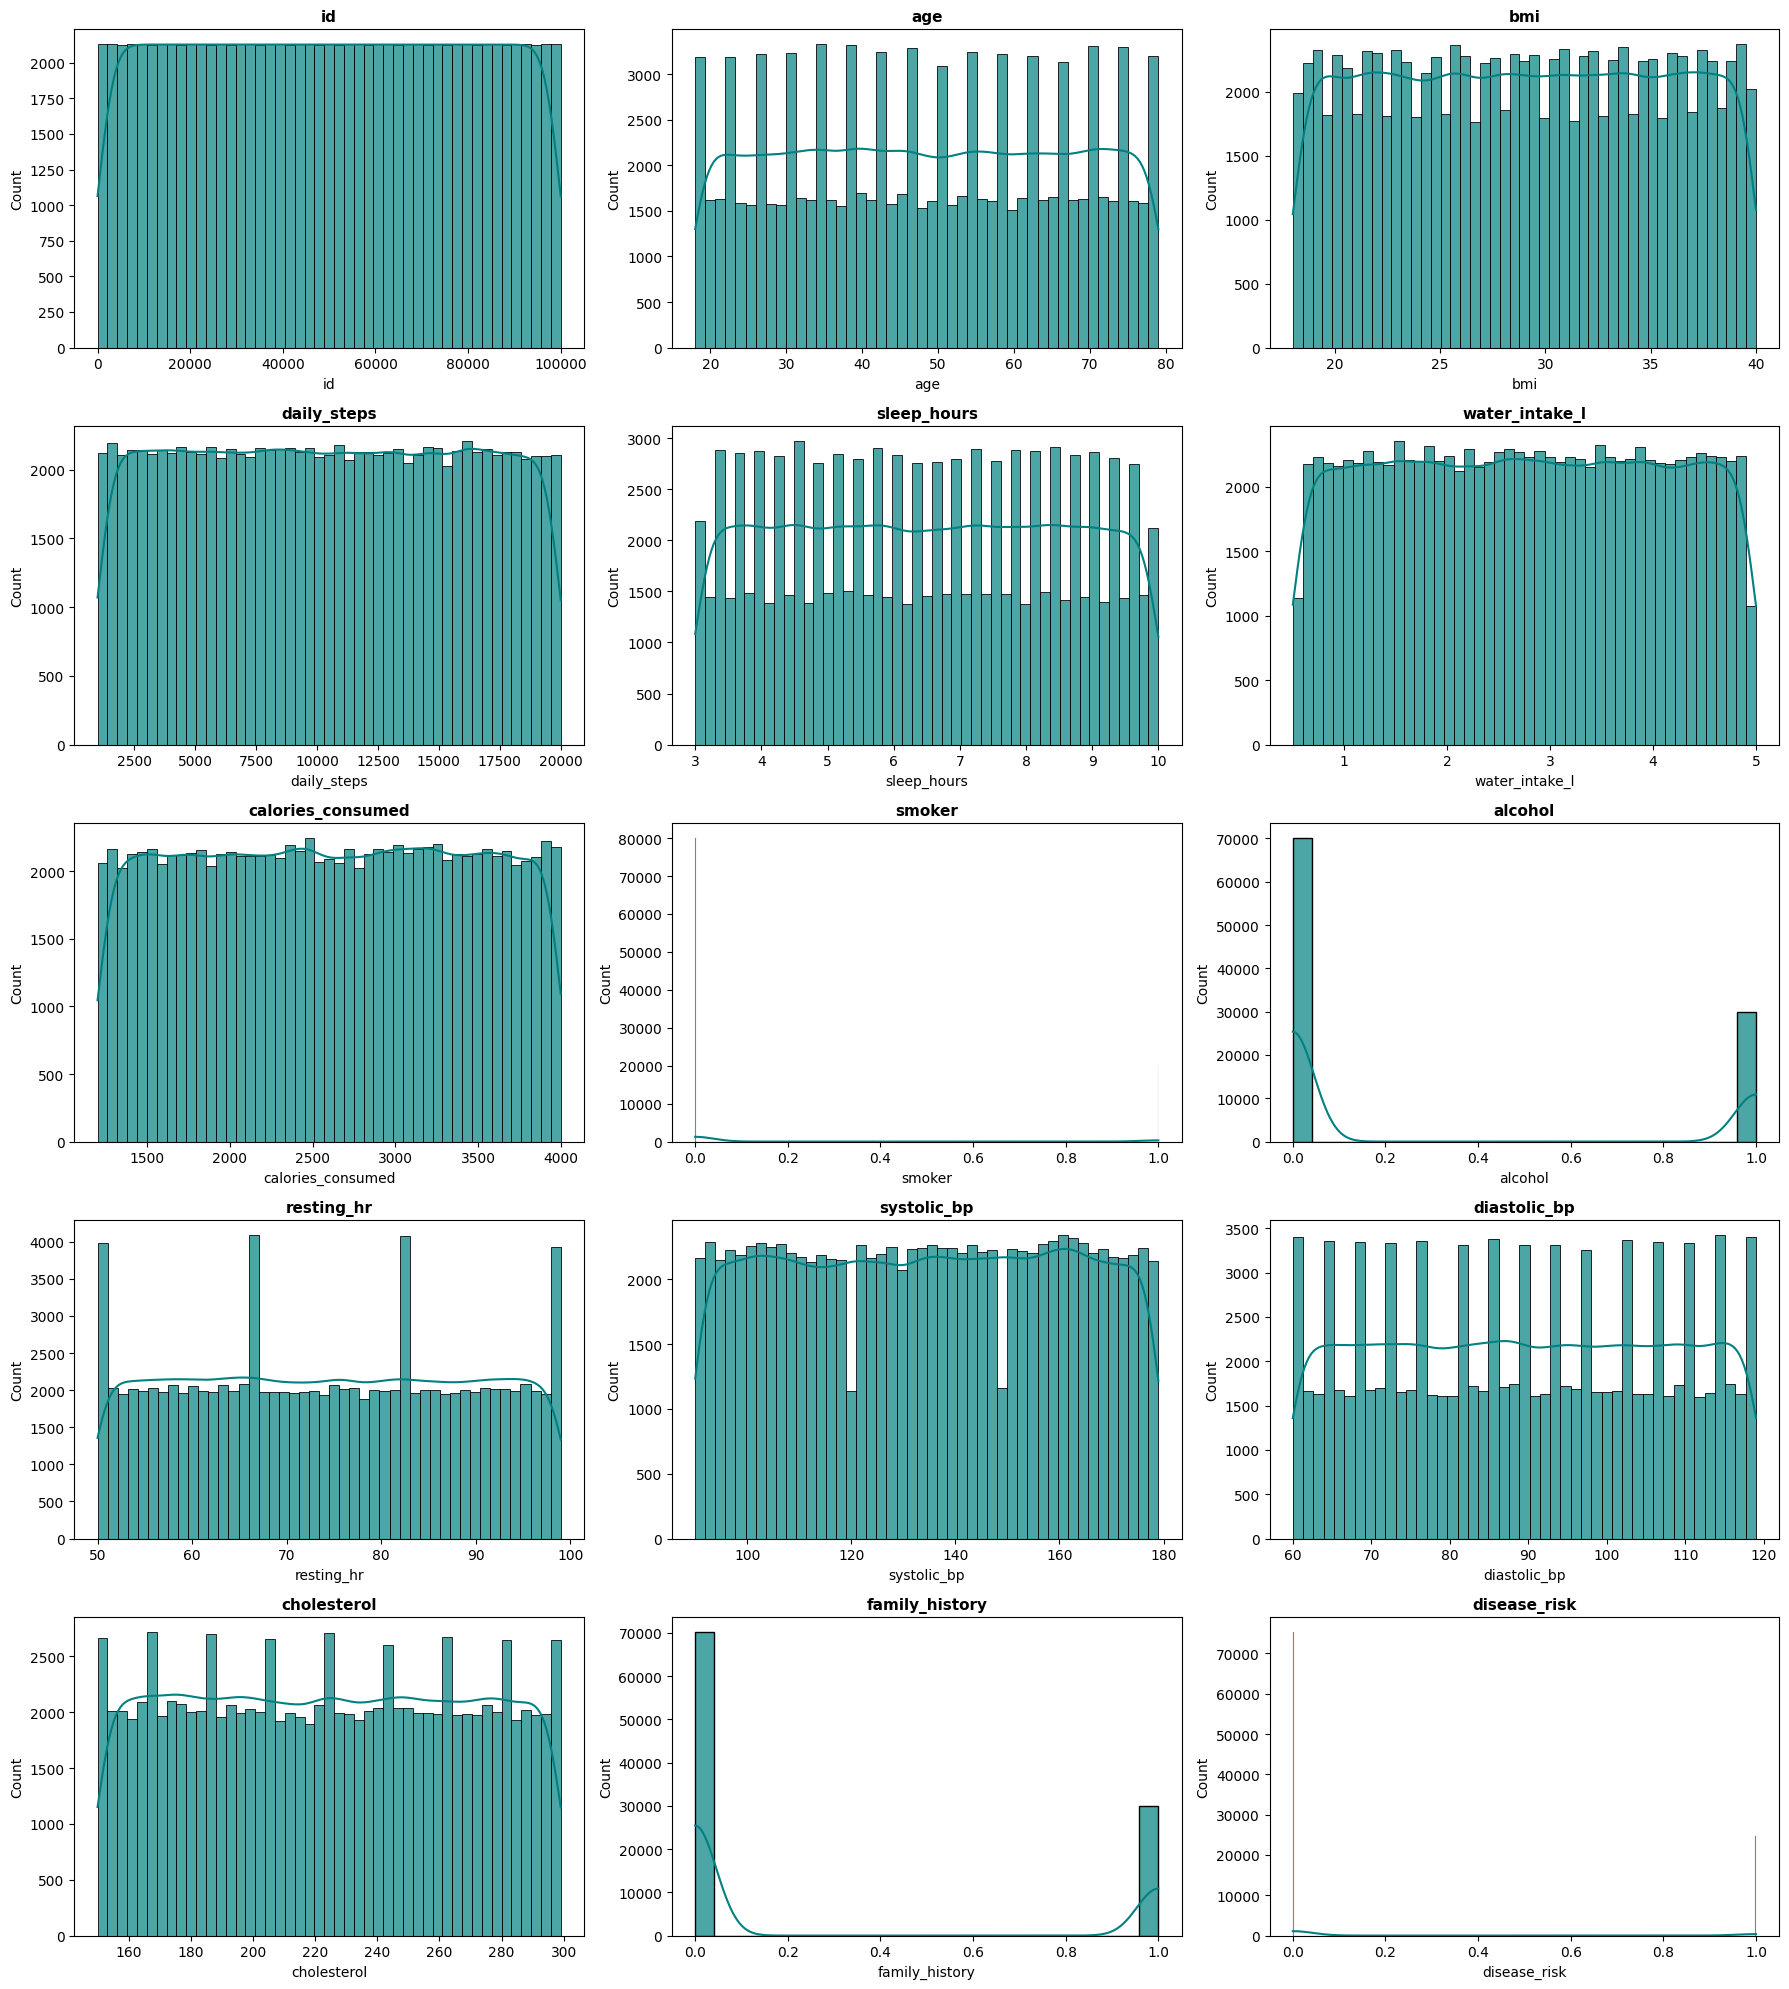

In [72]:
# Distribution Visual

num_cols = df_scaled.select_dtypes(include=np.number).columns

cols = 3  # jumlah kolom horizontal
rows = math.ceil(len(num_cols) / cols)

plt.figure(figsize=(18, 4*rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    
    sns.histplot(
        df[col].dropna(),
        kde=True,
        color='teal',
        edgecolor='black',
        alpha=0.7
    )
    
    plt.title(col, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Data Cleaning

In [73]:
# Memeriksa Unique Value
pd.set_option('display.max_colwidth', None)
unique_summary = pd.DataFrame({
    'n_unique': df.nunique(),
    'unique_values': df.apply(lambda x: x.unique())
})

unique_summary

,n_unique,unique_values
id,100000,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, ...]"
age,62,"[56, 69, 46, 32, 60, 25, 78, 38, 75, 36, 40, 28, 41, 70, 53, 57, 20, 39, 19, 61, 47, 55, 77, 50, 29, 42, 66, 44, 76, 59, 45, 33, 79, 64, 68, 72, 74, 54, 24, 26, 35, 21, 31, 67, 43, 37, 52, 34, 23, 71, 51, 27, 48, 65, 62, 58, 18, 22, 30, 49, 73, 63]"
gender,2,"[Male, Female]"
bmi,221,"[20.5, 33.3, 31.6, 38.2, 33.6, 27.3, 37.1, 18.9, 18.2, 23.5, 20.8, 23.9, 24.7, 28.0, 31.4, 25.8, 39.3, 29.9, 37.3, 35.7, 19.1, 28.4, 37.9, 31.9, 38.5, 32.6, 22.6, 30.3, 34.6, 32.7, 19.8, 23.2, 33.1, 29.6, 18.7, 34.2, 19.7, 22.1, 24.9, 18.8, 18.4, 38.6, 26.2, 31.7, 27.1, 22.7, 38.9, 39.7, 36.9, 21.9, 30.4, 30.8, 24.8, 29.3, 21.8, 38.8, 36.2, 21.1, 32.8, 27.0, 24.4, 36.4, 25.7, 27.7, 24.5, 22.2, 30.5, 34.0, 26.3, 21.6, 31.2, 37.0, 37.5, 37.2, 23.3, 34.4, 33.9, 21.7, 22.3, 20.4, 29.0, 25.1, 37.8, 40.0, 35.0, 28.2, 33.2, 27.5, 23.7, 30.6, 24.2, 25.2, 22.4, 22.9, 31.5, 23.8, 18.0, 20.3, 36.3, 22.5, ...]"
daily_steps,18921,"[4198, 14359, 1817, 15772, 6037, 19495, 16739, 1726, 1764, 9730, 17215, 10841, 10059, 3186, 15963, 18483, 14432, 2046, 6529, 1398, 6216, 19659, 19840, 7498, 4623, 16175, 15952, 12570, 8743, 9098, 12313, 1863, 15702, 6215, 2980, 14505, 3302, 5863, 7855, 18984, 14904, 3531, 18533, 8364, 7867, 3333, 5650, 10193, 12334, 15382, 15228, 5432, 11946, 19644, 17255, 15946, 2480, 5521, 16810, 16022, 11461, 4764, 11380, 18567, 15009, 15953, 5178, 11817, 9375, 15158, 3678, 17889, 7437, 3240, 9346, 18556, 18777, 12605, 15660, 2652, 5495, 13359, 13564, 15246, 11347, 17192, 5400, 11032, 3149, 1069, 15077, 14931, 3959, 12595, 5680, 5461, 6802, 10913, 9349, 6953, ...]"
sleep_hours,71,"[3.9, 9.0, 6.6, 3.6, 3.8, 5.0, 9.5, 4.8, 5.1, 4.5, 4.2, 6.5, 7.7, 3.7, 5.6, 9.7, 8.7, 8.5, 5.7, 9.3, 9.4, 7.3, 6.9, 9.8, 4.4, 9.6, 4.7, 8.3, 10.0, 8.2, 7.6, 7.2, 3.4, 5.3, 4.9, 3.1, 5.5, 6.2, 8.9, 4.3, 6.0, 9.1, 6.1, 6.8, 7.9, 4.6, 5.9, 6.3, 4.1, 8.0, 6.4, 5.8, 8.8, 8.6, 9.9, 7.1, 7.0, 7.8, 4.0, 5.4, 9.2, 8.1, 7.5, 8.4, 3.3, 7.4, 3.5, 5.2, 6.7, 3.0, 3.2]"
water_intake_l,46,"[3.4, 4.7, 4.2, 2.0, 4.0, 4.4, 1.7, 1.5, 0.7, 5.0, 2.8, 0.6, 1.4, 3.2, 3.1, 3.3, 4.1, 3.6, 2.2, 1.1, 3.9, 1.3, 3.7, 4.9, 1.0, 1.2, 1.9, 2.1, 4.8, 2.6, 0.9, 2.5, 0.8, 3.5, 2.4, 4.5, 4.3, 2.3, 4.6, 2.9, 2.7, 1.8, 3.8, 1.6, 3.0, 0.5]"
calories_consumed,2800,"[1602, 2346, 1643, 2460, 3756, 1301, 3478, 3212, 3740, 3571, 2732, 3858, 3281, 2978, 3274, 2759, 2349, 1506, 1336, 2161, 3232, 2814, 3365, 1887, 2595, 1605, 3762, 1470, 1412, 2531, 2495, 3051, 2695, 1649, 3017, 2669, 3990, 3607, 3083, 1650, 3891, 1736, 2588, 2430, 2955, 1835, 2129, 3496, 1285, 2635, 1740, 1925, 2712, 1418, 2735, 3964, 1259, 2555, 2594, 3494, 3505, 3313, 3244, 1389, 1275, 3539, 2461, 2145, 2817, 2309, 3434, 3431, 2481, 1715, 3629, 3271, 3411, 3054, 2354, 3144, 2246, 3437, 2167, 2974, 2961, 2671, 2205, 1992, 1379, 2653, 2824, 3143, 3357, 2772, 3532, 3998, 2213, 3551, 1202, 2918, ...]"
smoker,2,"[0, 1]"
alcohol,2,"[0, 1]"


In [74]:
# Melakukan pengecekan inkonsistensi kapitalisasi
object_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in object_cols:

    # Mengambil nilai unik asli (tanpa mengubah huruf)
    unique_original = df[col].dropna().unique()

    # Mengubah semua nilai menjadi huruf kecil lalu ambil nilai uniknya
    unique_lower = df[col].dropna().str.lower().unique()

    # Jika jumlah unik berbeda, berarti ada kemungkinan inkonsistensi
    if len(unique_original) != len(unique_lower):
        print(f"Kolom '{col}' kemungkinan ada inkonsistensi huruf besar/kecil")
        print("Contoh nilai unik:")
        print(unique_original[:10])
        print("-"*50)

Berdasarkan hasil pengecekan, tidak ditemukan perbedaan jumlah kategori sebelum dan sesudah konversi ke huruf kecil. Hal ini menunjukkan bahwa tidak terdapat inkonsistensi kapitalisasi pada kolom kategorikal.

In [75]:
# Memeriksa Outlier
num_cols = df.select_dtypes(include="number").columns

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_summary = pd.DataFrame({
    "Jumlah Outlier": ((df[num_cols] < lower) | (df[num_cols] > upper)).sum(),
    "Persentase Outlier (%)": (
        ((df[num_cols] < lower) | (df[num_cols] > upper)).sum() / len(df) * 100
    ).round(2),
    "Nilai Skewness": df[num_cols].skew()
})

outlier_summary

,Jumlah Outlier,Persentase Outlier (%),Nilai Skewness
id,0,0.00,-1.064188e-16
age,0,0.00,1.257826e-03
bmi,0,0.00,-3.501568e-03
daily_steps,0,0.00,3.412247e-03
sleep_hours,0,0.00,1.684842e-03
water_intake_l,0,0.00,-1.079543e-03
calories_consumed,0,0.00,-4.480698e-03
smoker,20094,20.09,1.492698e+00
alcohol,0,0.00,8.727807e-01
resting_hr,0,0.00,4.372816e-03


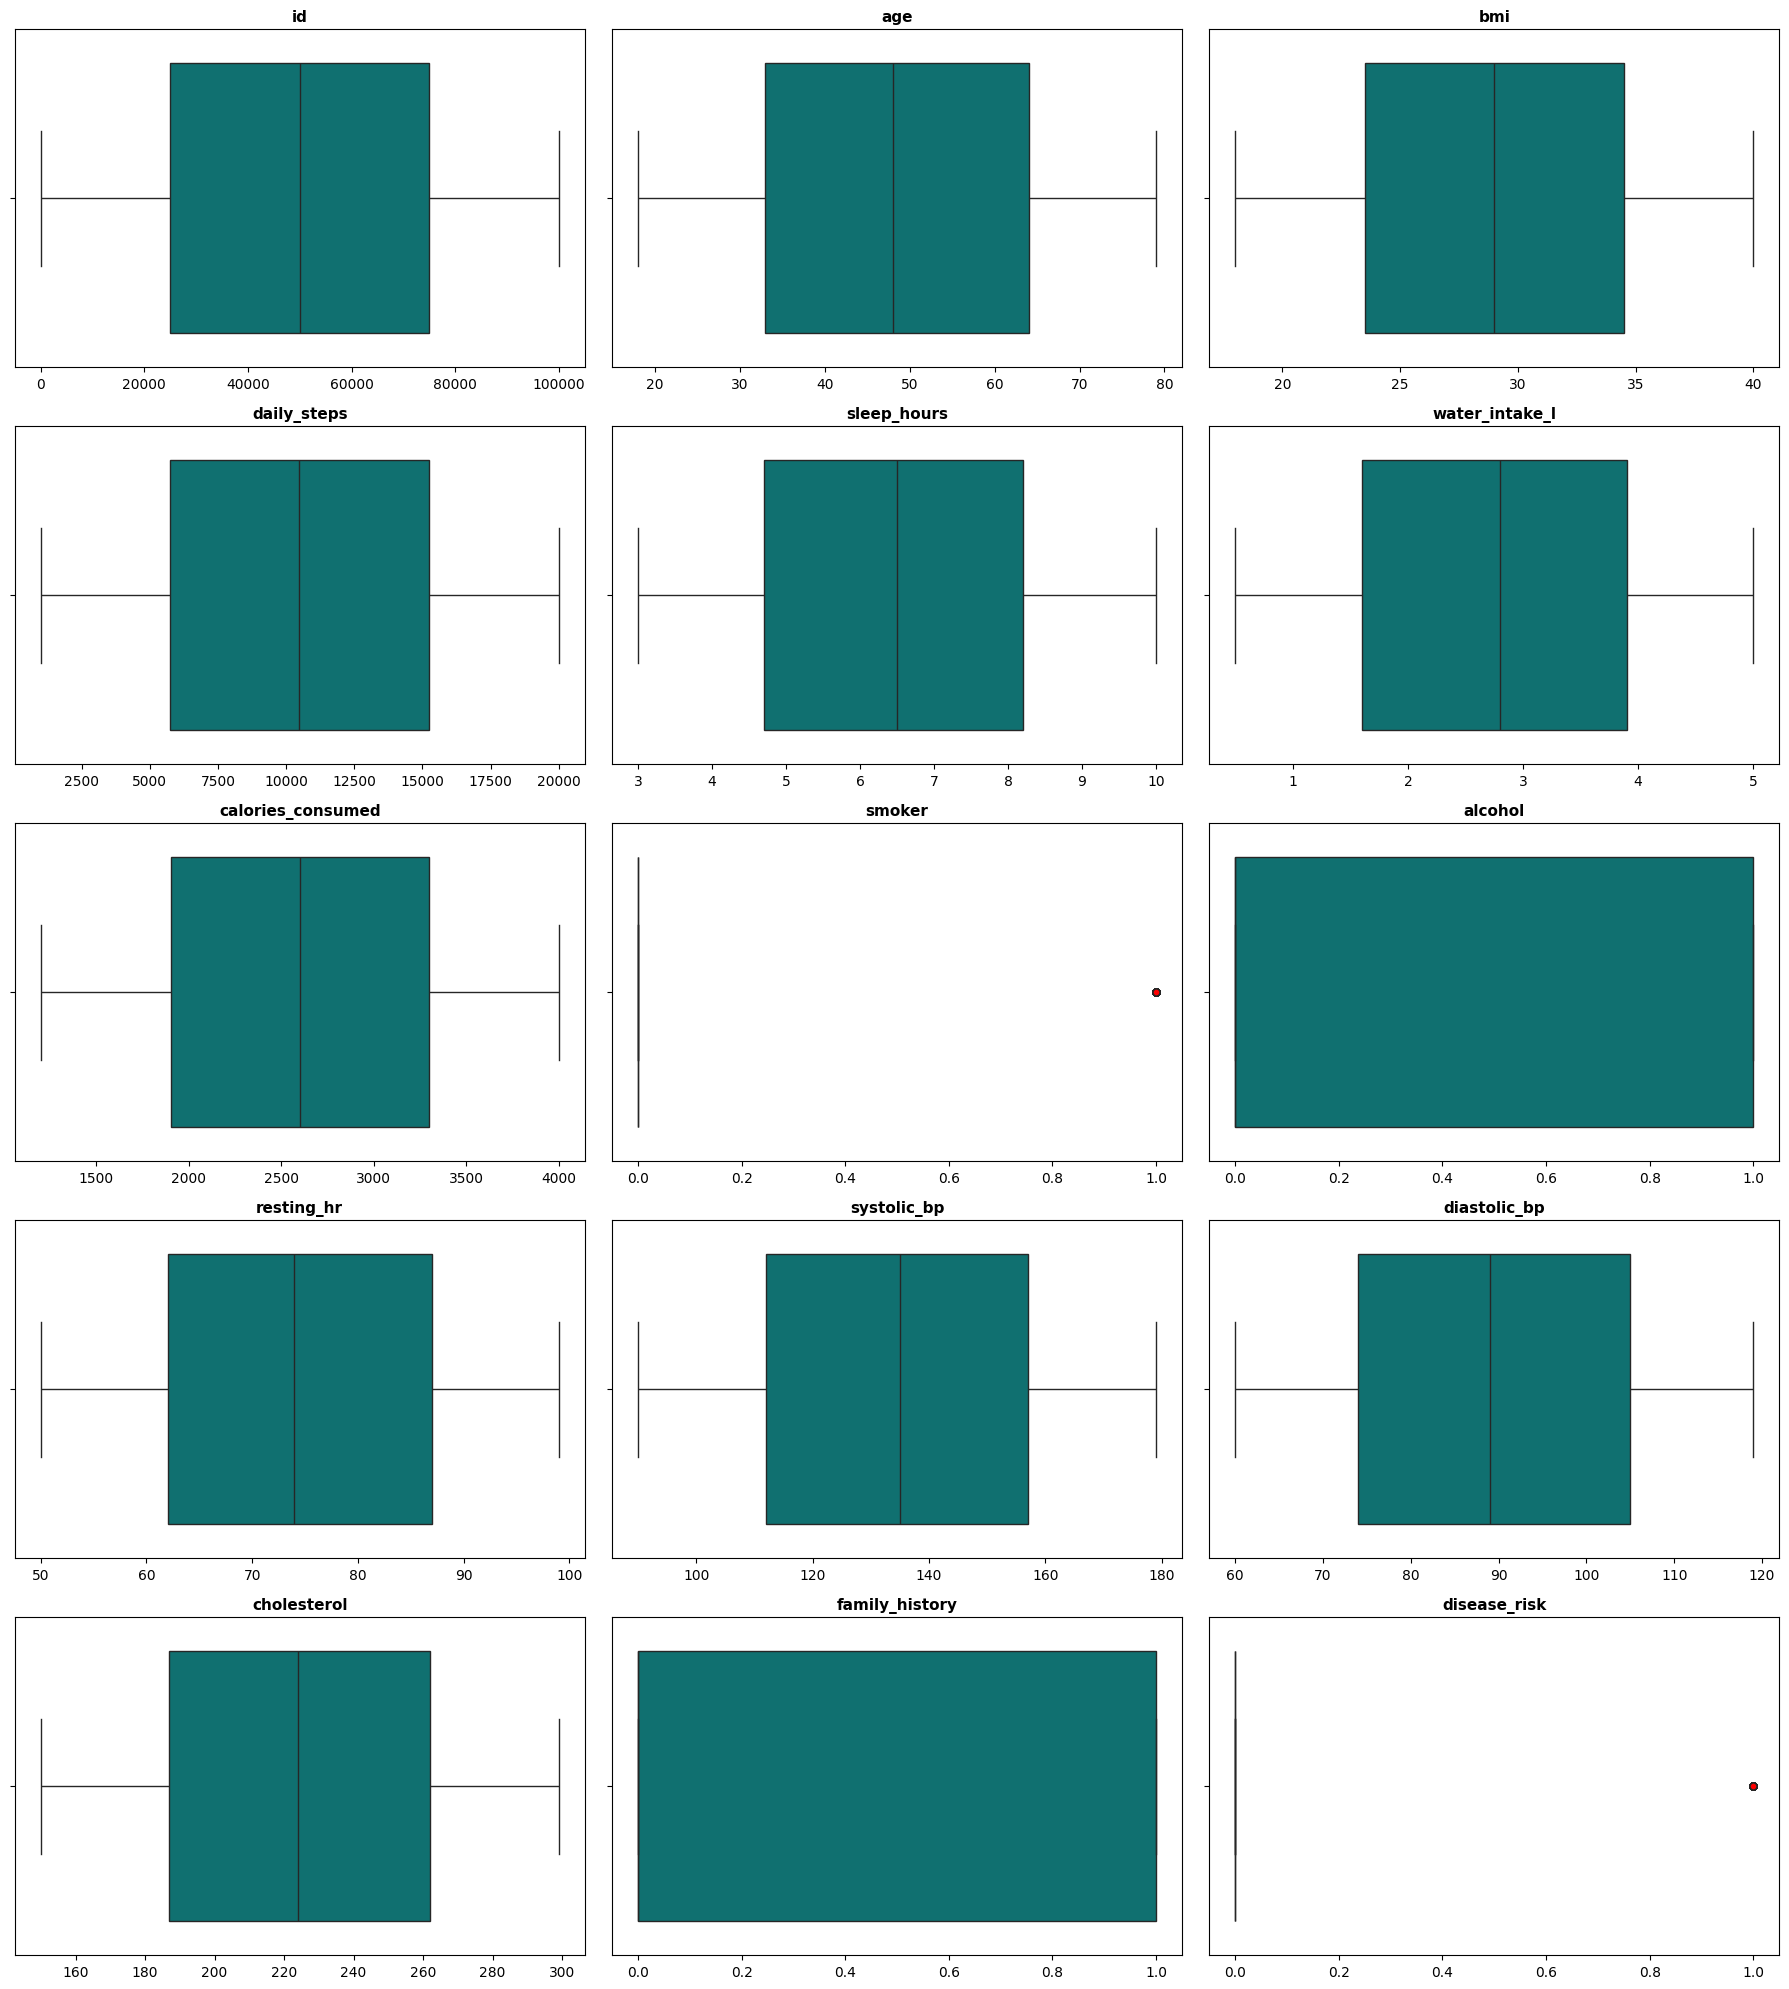

In [76]:
# Boxplot visual for outlier detection
num_cols = df.select_dtypes(include=np.number).columns

cols = 3
rows = math.ceil(len(num_cols) / cols)

plt.figure(figsize=(18, 4 * rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)

    sns.boxplot(
        x=df[col],
        color='teal',
        flierprops=dict(
            marker='o',
            markerfacecolor='red',
            markersize=5,
            linestyle='none'
        )
    )

    plt.title(col, fontsize=11, fontweight='bold')
    plt.xlabel("")

plt.tight_layout()
plt.show()

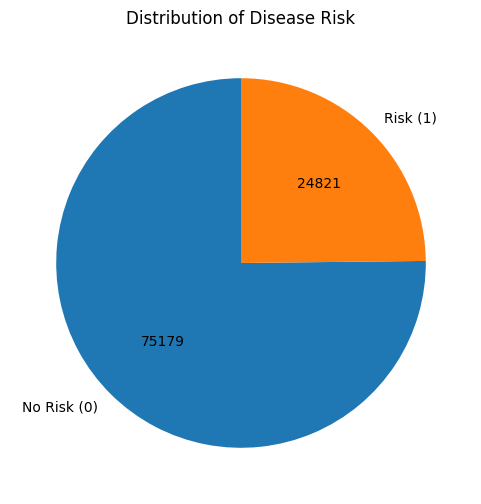

In [77]:
# Hitung jumlah tiap kategori
disease_counts = df['disease_risk'].value_counts().sort_index()

# Label kategori
labels = ['No Risk (0)', 'Risk (1)']

# Fungsi untuk menampilkan jumlah
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{count}'
    return my_format

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    disease_counts,
    labels=labels,
    autopct=autopct_format(disease_counts),
    startangle=90
)

plt.title('Distribution of Disease Risk')
plt.show()

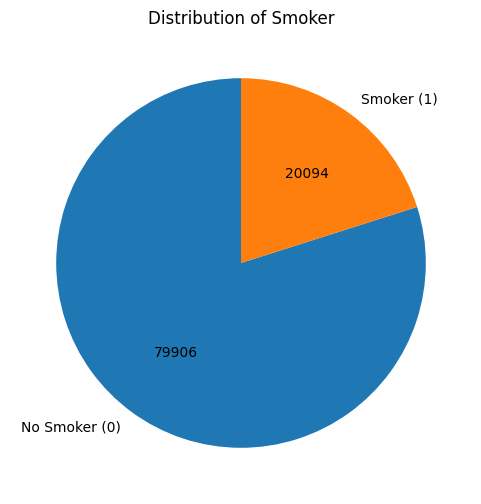

In [78]:
# Hitung jumlah tiap kategori
smoker_counts = df['smoker'].value_counts().sort_index()

# Label kategori
labels = ['No Smoker (0)', 'Smoker (1)']

# Fungsi untuk menampilkan jumlah
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{count}'
    return my_format

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    smoker_counts,
    labels=labels,
    autopct=autopct_format(smoker_counts),
    startangle=90
)

plt.title('Distribution of Smoker')
plt.show()

Outlier yang muncul pada variabel **smoker** dan **disease_risk** kemungkinan besar bukan outlier yang sebenarnya, karena kedua variabel tersebut adalah variabel kategorikal yang diubah menjadi angka biner.
Nilai 0 dan 1 bisa saja terdeteksi sebagai outlier ketika menggunakan metode seperti boxplot, IQR, atau Z-score, karena metode tersebut dirancang untuk data numerik yang bersifat kontinu, bukan untuk variabel kategorikal.

# Feature Engineering

In [81]:
df_baru = df.copy()

In [82]:
# membuat Age Group
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 40, 60, 100],
    labels=['Young Adult', 'Adult', 'Middle Age', 'Elderly']
)
df_baru.head(20)

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,age_group
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0,Middle Age
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0,Elderly
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0,Middle Age
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0,Adult
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0,Middle Age
5,6,25,Male,27.3,19495,5.0,4.4,1301,0,1,73,107,65,284,0,0,Young Adult
6,7,78,Female,37.1,16739,9.5,4.2,3478,1,0,90,110,102,201,0,0,Elderly
7,8,38,Female,18.9,1726,4.8,1.7,3212,0,1,64,113,109,197,0,0,Adult
8,9,56,Female,18.2,1764,5.1,1.5,3740,0,1,91,112,61,237,1,0,Middle Age
9,10,75,Male,23.5,9730,4.5,0.7,3571,0,1,54,177,90,157,1,0,Elderly


In [83]:
# Membuat BMI category menggunakan lambda
df_baru['bmi_category'] = df_baru['bmi'].apply(
    lambda x: 'Underweight' if x < 18.5
    else 'Normal' if x < 25
    else 'Overweight' if x < 30
    else 'Obese'
)

# Melihat hasilnya
df_baru.head(20)

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,age_group,bmi_category
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0,Middle Age,Normal
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0,Elderly,Obese
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0,Middle Age,Obese
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0,Adult,Obese
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0,Middle Age,Obese
5,6,25,Male,27.3,19495,5.0,4.4,1301,0,1,73,107,65,284,0,0,Young Adult,Overweight
6,7,78,Female,37.1,16739,9.5,4.2,3478,1,0,90,110,102,201,0,0,Elderly,Obese
7,8,38,Female,18.9,1726,4.8,1.7,3212,0,1,64,113,109,197,0,0,Adult,Normal
8,9,56,Female,18.2,1764,5.1,1.5,3740,0,1,91,112,61,237,1,0,Middle Age,Underweight
9,10,75,Male,23.5,9730,4.5,0.7,3571,0,1,54,177,90,157,1,0,Elderly,Normal


In [84]:
(df_baru['bmi_category'].value_counts(normalize=True) * 100).round(2)

bmi_category
Obese          45.85
Normal         29.39
Overweight     22.76
Underweight     1.99
Name: proportion, dtype: float64

In [85]:
# membuat blood pressure category
df_baru['systolic_category'] = df_baru['systolic_bp'].apply(
    lambda x: 'Normal' if x < 120
    else 'Elevated' if x < 130
    else 'Hypertension Stage 1' if x < 140
    else 'Hypertension Stage 2'
)
df_baru.head(10)

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,age_group,bmi_category,systolic_category
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0,Middle Age,Normal,Hypertension Stage 2
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0,Elderly,Obese,Normal
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0,Middle Age,Obese,Elevated
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0,Adult,Obese,Hypertension Stage 2
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0,Middle Age,Obese,Hypertension Stage 1
5,6,25,Male,27.3,19495,5.0,4.4,1301,0,1,73,107,65,284,0,0,Young Adult,Overweight,Normal
6,7,78,Female,37.1,16739,9.5,4.2,3478,1,0,90,110,102,201,0,0,Elderly,Obese,Normal
7,8,38,Female,18.9,1726,4.8,1.7,3212,0,1,64,113,109,197,0,0,Adult,Normal,Normal
8,9,56,Female,18.2,1764,5.1,1.5,3740,0,1,91,112,61,237,1,0,Middle Age,Underweight,Normal
9,10,75,Male,23.5,9730,4.5,0.7,3571,0,1,54,177,90,157,1,0,Elderly,Normal,Hypertension Stage 2


In [86]:
df_baru['diastolic_category'] = df_baru['diastolic_bp'].apply(
    lambda x: 'Normal' if x < 80
    else 'Hypertension Stage 1' if x < 90
    else 'Hypertension Stage 2'
)
df_baru.head(20)

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,age_group,bmi_category,systolic_category,diastolic_category
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0,Middle Age,Normal,Hypertension Stage 2,Hypertension Stage 2
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0,Elderly,Obese,Normal,Normal
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0,Middle Age,Obese,Elevated,Hypertension Stage 2
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0,Adult,Obese,Hypertension Stage 2,Hypertension Stage 2
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0,Middle Age,Obese,Hypertension Stage 1,Normal
5,6,25,Male,27.3,19495,5.0,4.4,1301,0,1,73,107,65,284,0,0,Young Adult,Overweight,Normal,Normal
6,7,78,Female,37.1,16739,9.5,4.2,3478,1,0,90,110,102,201,0,0,Elderly,Obese,Normal,Hypertension Stage 2
7,8,38,Female,18.9,1726,4.8,1.7,3212,0,1,64,113,109,197,0,0,Adult,Normal,Normal,Hypertension Stage 2
8,9,56,Female,18.2,1764,5.1,1.5,3740,0,1,91,112,61,237,1,0,Middle Age,Underweight,Normal,Normal
9,10,75,Male,23.5,9730,4.5,0.7,3571,0,1,54,177,90,157,1,0,Elderly,Normal,Hypertension Stage 2,Hypertension Stage 2


In [87]:
df_baru['cholesterol_category'] = df_baru['cholesterol'].apply(
    lambda x: 'Desirable' if x < 200
    else 'Borderline High' if x < 240
    else 'High'
)
df_baru.head(20)

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,age_group,bmi_category,systolic_category,diastolic_category,cholesterol_category
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0,Middle Age,Normal,Hypertension Stage 2,Hypertension Stage 2,High
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0,Elderly,Obese,Normal,Normal,Borderline High
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0,Middle Age,Obese,Elevated,Hypertension Stage 2,High
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0,Adult,Obese,Hypertension Stage 2,Hypertension Stage 2,Desirable
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0,Middle Age,Obese,Hypertension Stage 1,Normal,High
5,6,25,Male,27.3,19495,5.0,4.4,1301,0,1,73,107,65,284,0,0,Young Adult,Overweight,Normal,Normal,High
6,7,78,Female,37.1,16739,9.5,4.2,3478,1,0,90,110,102,201,0,0,Elderly,Obese,Normal,Hypertension Stage 2,Borderline High
7,8,38,Female,18.9,1726,4.8,1.7,3212,0,1,64,113,109,197,0,0,Adult,Normal,Normal,Hypertension Stage 2,Desirable
8,9,56,Female,18.2,1764,5.1,1.5,3740,0,1,91,112,61,237,1,0,Middle Age,Underweight,Normal,Normal,Borderline High
9,10,75,Male,23.5,9730,4.5,0.7,3571,0,1,54,177,90,157,1,0,Elderly,Normal,Hypertension Stage 2,Hypertension Stage 2,Desirable


In [88]:
high_risk = df_baru[
    (df_baru['systolic_bp'] > 120) &
    (df_baru['diastolic_bp'] > 80) &
    (df_baru['cholesterol'] > 200)
]
high_risk

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,age_group,bmi_category,systolic_category,diastolic_category,cholesterol_category
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0,Middle Age,Normal,Hypertension Stage 2,Hypertension Stage 2,High
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0,Middle Age,Obese,Elevated,Hypertension Stage 2,High
12,13,28,Male,24.7,10059,6.5,2.8,3281,0,0,87,129,88,224,1,0,Adult,Normal,Elevated,Hypertension Stage 1,Borderline High
14,15,41,Male,31.4,15963,3.7,2.0,3274,0,0,81,148,99,278,1,0,Middle Age,Obese,Hypertension Stage 2,Hypertension Stage 2,High
19,20,20,Male,35.7,1398,8.5,3.3,2161,0,0,57,167,100,272,1,0,Young Adult,Obese,Hypertension Stage 2,Hypertension Stage 2,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99983,99984,19,Female,21.2,9882,3.9,1.2,2344,0,0,54,150,87,259,0,0,Young Adult,Normal,Hypertension Stage 2,Hypertension Stage 1,High
99985,99986,67,Male,34.5,3207,8.0,4.2,2051,0,0,82,157,95,286,1,0,Elderly,Obese,Hypertension Stage 2,Hypertension Stage 2,High
99989,99990,24,Female,35.4,12177,7.2,2.8,1495,0,0,66,169,90,242,0,1,Young Adult,Obese,Hypertension Stage 2,Hypertension Stage 2,High
99992,99993,44,Female,32.9,6644,7.2,3.9,3193,0,0,78,135,107,236,0,0,Middle Age,Obese,Hypertension Stage 1,Hypertension Stage 2,Borderline High


In [89]:
high_risk_no_lifestyle = df_baru[
    (df_baru['systolic_bp'] > 120) &
    (df_baru['diastolic_bp'] > 80) &
    (df_baru['cholesterol'] > 200) &
    (df_baru['smoker'] == 0) &
    (df_baru['alcohol'] == 0)
]
high_risk_no_lifestyle.head(20)

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,age_group,bmi_category,systolic_category,diastolic_category,cholesterol_category
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0,Middle Age,Normal,Hypertension Stage 2,Hypertension Stage 2,High
12,13,28,Male,24.7,10059,6.5,2.8,3281,0,0,87,129,88,224,1,0,Adult,Normal,Elevated,Hypertension Stage 1,Borderline High
14,15,41,Male,31.4,15963,3.7,2.0,3274,0,0,81,148,99,278,1,0,Middle Age,Obese,Hypertension Stage 2,Hypertension Stage 2,High
19,20,20,Male,35.7,1398,8.5,3.3,2161,0,0,57,167,100,272,1,0,Young Adult,Obese,Hypertension Stage 2,Hypertension Stage 2,High
30,31,50,Female,32.7,12313,4.7,4.9,2495,0,0,94,178,81,243,1,0,Middle Age,Obese,Hypertension Stage 2,Hypertension Stage 1,High
31,32,29,Female,19.8,1863,8.3,1.3,3051,0,0,74,145,113,234,1,0,Adult,Normal,Hypertension Stage 2,Hypertension Stage 2,Borderline High
32,33,75,Male,23.2,15702,10.0,1.0,2695,0,0,64,125,106,252,0,0,Elderly,Normal,Elevated,Hypertension Stage 2,High
34,35,78,Female,29.6,2980,7.6,1.9,3017,0,0,78,159,100,208,0,0,Elderly,Overweight,Hypertension Stage 2,Hypertension Stage 2,Borderline High
40,41,59,Female,24.9,14904,9.5,0.9,3891,0,0,90,123,106,281,0,1,Middle Age,Normal,Elevated,Hypertension Stage 2,High
43,44,33,Male,38.6,8364,5.3,3.1,2430,0,0,97,123,90,276,1,0,Adult,Obese,Elevated,Hypertension Stage 2,High


In [90]:
# Filter usia < 20 tahun dengan kondisi tekanan darah dan cholesterol tertentu
df_under20 = df_baru[
    (df_baru['age'] < 20) &
    (df_baru['systolic_bp'] > 128) &
    (df_baru['diastolic_bp'] > 80) &
    (df_baru['cholesterol'] > 200)
]

# Sorting berdasarkan usia (termuda → tertua)
df_under20 = df_under20.sort_values(by='age', ascending=True)

# Melihat hasil beberapa baris
df_under20[['age','systolic_bp','diastolic_bp','cholesterol']].head()

,age,systolic_bp,diastolic_bp,cholesterol
131,18,155,105,289
58538,18,132,83,285
58245,18,175,87,232
58128,18,131,99,277
57800,18,143,116,281


Beberapa individu usia 18 tahun sudah menunjukkan tekanan darah dan kadar kolesterol yang tinggi, yang dapat menjadi indikasi risiko kesehatan jantung sejak usia muda.

In [91]:
def steps_category(steps):
    if steps < 5000:
        return "Sedentary"
    elif steps < 8000:
        return "Low Active"
    elif steps < 10000:
        return "Moderately Active"
    else:
        return "Active"

df_baru['steps_category'] = df_baru['daily_steps'].apply(steps_category)
df_baru.tail(20)

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,age_group,bmi_category,systolic_category,diastolic_category,cholesterol_category,steps_category
99980,99981,64,Male,19.8,15650,6.3,2.7,2058,0,0,56,106,86,228,0,0,Elderly,Normal,Normal,Hypertension Stage 1,Borderline High,Active
99981,99982,69,Male,22.2,5137,4.7,2.9,3420,0,0,81,146,109,202,0,0,Elderly,Normal,Hypertension Stage 2,Hypertension Stage 2,Borderline High,Low Active
99982,99983,22,Female,36.1,17181,9.3,3.1,1433,0,1,90,163,110,205,0,0,Young Adult,Obese,Hypertension Stage 2,Hypertension Stage 2,Borderline High,Active
99983,99984,19,Female,21.2,9882,3.9,1.2,2344,0,0,54,150,87,259,0,0,Young Adult,Normal,Hypertension Stage 2,Hypertension Stage 1,High,Moderately Active
99984,99985,58,Female,23.1,6532,6.0,4.9,1874,0,0,50,170,115,163,1,1,Middle Age,Normal,Hypertension Stage 2,Hypertension Stage 2,Desirable,Low Active
99985,99986,67,Male,34.5,3207,8.0,4.2,2051,0,0,82,157,95,286,1,0,Elderly,Obese,Hypertension Stage 2,Hypertension Stage 2,High,Sedentary
99986,99987,62,Male,30.9,6133,5.3,3.8,2280,1,0,55,161,87,194,0,0,Elderly,Obese,Hypertension Stage 2,Hypertension Stage 1,Desirable,Low Active
99987,99988,37,Female,36.0,4764,9.1,3.4,2602,0,0,69,150,103,190,1,0,Adult,Obese,Hypertension Stage 2,Hypertension Stage 2,Desirable,Sedentary
99988,99989,73,Male,28.3,8929,3.1,1.1,1996,0,0,87,92,90,269,0,0,Elderly,Overweight,Normal,Hypertension Stage 2,High,Moderately Active
99989,99990,24,Female,35.4,12177,7.2,2.8,1495,0,0,66,169,90,242,0,1,Young Adult,Obese,Hypertension Stage 2,Hypertension Stage 2,High,Active


In [92]:
def sleep_category(hours):
    if hours < 5:
        return "Very Short Sleep"
    elif hours <= 8:
        return "Optimal Sleep"
    else:
        return "Long Sleep"

df_baru['sleep_category'] = df_baru['sleep_hours'].apply(sleep_category)
df_baru.tail(20)

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,age_group,bmi_category,systolic_category,diastolic_category,cholesterol_category,steps_category,sleep_category
99980,99981,64,Male,19.8,15650,6.3,2.7,2058,0,0,56,106,86,228,0,0,Elderly,Normal,Normal,Hypertension Stage 1,Borderline High,Active,Optimal Sleep
99981,99982,69,Male,22.2,5137,4.7,2.9,3420,0,0,81,146,109,202,0,0,Elderly,Normal,Hypertension Stage 2,Hypertension Stage 2,Borderline High,Low Active,Very Short Sleep
99982,99983,22,Female,36.1,17181,9.3,3.1,1433,0,1,90,163,110,205,0,0,Young Adult,Obese,Hypertension Stage 2,Hypertension Stage 2,Borderline High,Active,Long Sleep
99983,99984,19,Female,21.2,9882,3.9,1.2,2344,0,0,54,150,87,259,0,0,Young Adult,Normal,Hypertension Stage 2,Hypertension Stage 1,High,Moderately Active,Very Short Sleep
99984,99985,58,Female,23.1,6532,6.0,4.9,1874,0,0,50,170,115,163,1,1,Middle Age,Normal,Hypertension Stage 2,Hypertension Stage 2,Desirable,Low Active,Optimal Sleep
99985,99986,67,Male,34.5,3207,8.0,4.2,2051,0,0,82,157,95,286,1,0,Elderly,Obese,Hypertension Stage 2,Hypertension Stage 2,High,Sedentary,Optimal Sleep
99986,99987,62,Male,30.9,6133,5.3,3.8,2280,1,0,55,161,87,194,0,0,Elderly,Obese,Hypertension Stage 2,Hypertension Stage 1,Desirable,Low Active,Optimal Sleep
99987,99988,37,Female,36.0,4764,9.1,3.4,2602,0,0,69,150,103,190,1,0,Adult,Obese,Hypertension Stage 2,Hypertension Stage 2,Desirable,Sedentary,Long Sleep
99988,99989,73,Male,28.3,8929,3.1,1.1,1996,0,0,87,92,90,269,0,0,Elderly,Overweight,Normal,Hypertension Stage 2,High,Moderately Active,Very Short Sleep
99989,99990,24,Female,35.4,12177,7.2,2.8,1495,0,0,66,169,90,242,0,1,Young Adult,Obese,Hypertension Stage 2,Hypertension Stage 2,High,Active,Optimal Sleep


In [93]:
def water_category(water):
    if water < 1.5:
        return "Low Hydration"
    elif water < 2.5:
        return "Adequate Hydration"
    else:
        return "High Hydration"

df_baru['water_category'] = df_baru['water_intake_l'].apply(water_category)
df_baru.head(20)

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,age_group,bmi_category,systolic_category,diastolic_category,cholesterol_category,steps_category,sleep_category,water_category
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0,Middle Age,Normal,Hypertension Stage 2,Hypertension Stage 2,High,Sedentary,Very Short Sleep,High Hydration
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0,Elderly,Obese,Normal,Normal,Borderline High,Active,Long Sleep,High Hydration
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0,Middle Age,Obese,Elevated,Hypertension Stage 2,High,Sedentary,Optimal Sleep,High Hydration
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0,Adult,Obese,Hypertension Stage 2,Hypertension Stage 2,Desirable,Active,Very Short Sleep,Adequate Hydration
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0,Middle Age,Obese,Hypertension Stage 1,Normal,High,Low Active,Very Short Sleep,High Hydration
5,6,25,Male,27.3,19495,5.0,4.4,1301,0,1,73,107,65,284,0,0,Young Adult,Overweight,Normal,Normal,High,Active,Optimal Sleep,High Hydration
6,7,78,Female,37.1,16739,9.5,4.2,3478,1,0,90,110,102,201,0,0,Elderly,Obese,Normal,Hypertension Stage 2,Borderline High,Active,Long Sleep,High Hydration
7,8,38,Female,18.9,1726,4.8,1.7,3212,0,1,64,113,109,197,0,0,Adult,Normal,Normal,Hypertension Stage 2,Desirable,Sedentary,Very Short Sleep,Adequate Hydration
8,9,56,Female,18.2,1764,5.1,1.5,3740,0,1,91,112,61,237,1,0,Middle Age,Underweight,Normal,Normal,Borderline High,Sedentary,Optimal Sleep,Adequate Hydration
9,10,75,Male,23.5,9730,4.5,0.7,3571,0,1,54,177,90,157,1,0,Elderly,Normal,Hypertension Stage 2,Hypertension Stage 2,Desirable,Moderately Active,Very Short Sleep,Low Hydration


In [94]:
def calories_category(cal):
    if cal < 1800:
        return "Low Calorie Intake"
    elif cal < 2500:
        return "Normal Intake"
    else:
        return "High Calorie Intake"

df_baru['calories_category'] = df_baru['calories_consumed'].apply(calories_category)
df_baru.tail(20)

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,age_group,bmi_category,systolic_category,diastolic_category,cholesterol_category,steps_category,sleep_category,water_category,calories_category
99980,99981,64,Male,19.8,15650,6.3,2.7,2058,0,0,56,106,86,228,0,0,Elderly,Normal,Normal,Hypertension Stage 1,Borderline High,Active,Optimal Sleep,High Hydration,Normal Intake
99981,99982,69,Male,22.2,5137,4.7,2.9,3420,0,0,81,146,109,202,0,0,Elderly,Normal,Hypertension Stage 2,Hypertension Stage 2,Borderline High,Low Active,Very Short Sleep,High Hydration,High Calorie Intake
99982,99983,22,Female,36.1,17181,9.3,3.1,1433,0,1,90,163,110,205,0,0,Young Adult,Obese,Hypertension Stage 2,Hypertension Stage 2,Borderline High,Active,Long Sleep,High Hydration,Low Calorie Intake
99983,99984,19,Female,21.2,9882,3.9,1.2,2344,0,0,54,150,87,259,0,0,Young Adult,Normal,Hypertension Stage 2,Hypertension Stage 1,High,Moderately Active,Very Short Sleep,Low Hydration,Normal Intake
99984,99985,58,Female,23.1,6532,6.0,4.9,1874,0,0,50,170,115,163,1,1,Middle Age,Normal,Hypertension Stage 2,Hypertension Stage 2,Desirable,Low Active,Optimal Sleep,High Hydration,Normal Intake
99985,99986,67,Male,34.5,3207,8.0,4.2,2051,0,0,82,157,95,286,1,0,Elderly,Obese,Hypertension Stage 2,Hypertension Stage 2,High,Sedentary,Optimal Sleep,High Hydration,Normal Intake
99986,99987,62,Male,30.9,6133,5.3,3.8,2280,1,0,55,161,87,194,0,0,Elderly,Obese,Hypertension Stage 2,Hypertension Stage 1,Desirable,Low Active,Optimal Sleep,High Hydration,Normal Intake
99987,99988,37,Female,36.0,4764,9.1,3.4,2602,0,0,69,150,103,190,1,0,Adult,Obese,Hypertension Stage 2,Hypertension Stage 2,Desirable,Sedentary,Long Sleep,High Hydration,High Calorie Intake
99988,99989,73,Male,28.3,8929,3.1,1.1,1996,0,0,87,92,90,269,0,0,Elderly,Overweight,Normal,Hypertension Stage 2,High,Moderately Active,Very Short Sleep,Low Hydration,Normal Intake
99989,99990,24,Female,35.4,12177,7.2,2.8,1495,0,0,66,169,90,242,0,1,Young Adult,Obese,Hypertension Stage 2,Hypertension Stage 2,High,Active,Optimal Sleep,High Hydration,Low Calorie Intake


In [95]:
df_baru['lifestyle_risk'] = (
    (df_baru['daily_steps'] < 6000).astype(int) +
    (df_baru['sleep_hours'] < 6).astype(int) +
    (df_baru['water_intake_l'] < 1.5).astype(int) +
    (df_baru['calories_consumed'] > 2500).astype(int)
)

In [96]:
def lifestyle_category(score):
    if score <= 1:
        return "Healthy Lifestyle"
    elif score <= 2:
        return "Moderate Risk"
    else:
        return "High Risk"

df_baru['lifestyle_category'] = df_baru['lifestyle_risk'].apply(lifestyle_category)
df_baru

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,age_group,bmi_category,systolic_category,diastolic_category,cholesterol_category,steps_category,sleep_category,water_category,calories_category,lifestyle_risk,lifestyle_category
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0,Middle Age,Normal,Hypertension Stage 2,Hypertension Stage 2,High,Sedentary,Very Short Sleep,High Hydration,Low Calorie Intake,2,Moderate Risk
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0,Elderly,Obese,Normal,Normal,Borderline High,Active,Long Sleep,High Hydration,Normal Intake,0,Healthy Lifestyle
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0,Middle Age,Obese,Elevated,Hypertension Stage 2,High,Sedentary,Optimal Sleep,High Hydration,Low Calorie Intake,1,Healthy Lifestyle
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0,Adult,Obese,Hypertension Stage 2,Hypertension Stage 2,Desirable,Active,Very Short Sleep,Adequate Hydration,Normal Intake,1,Healthy Lifestyle
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0,Middle Age,Obese,Hypertension Stage 1,Normal,High,Low Active,Very Short Sleep,High Hydration,High Calorie Intake,2,Moderate Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,53,Male,33.1,4726,3.9,2.0,3118,0,1,56,105,76,282,0,0,Middle Age,Obese,Normal,Normal,High,Sedentary,Very Short Sleep,Adequate Hydration,High Calorie Intake,3,High Risk
99996,99997,22,Male,35.1,11554,4.5,3.1,1967,0,0,51,149,77,192,0,0,Young Adult,Obese,Hypertension Stage 2,Normal,Desirable,Active,Very Short Sleep,High Hydration,Normal Intake,1,Healthy Lifestyle
99997,99998,37,Male,18.9,3924,3.8,1.0,2328,0,0,69,92,117,218,0,0,Adult,Normal,Normal,Hypertension Stage 2,Borderline High,Sedentary,Very Short Sleep,Low Hydration,Normal Intake,3,High Risk
99998,99999,72,Female,27.8,16110,5.6,0.8,3093,0,0,93,164,72,188,0,0,Elderly,Overweight,Hypertension Stage 2,Normal,Desirable,Active,Optimal Sleep,Low Hydration,High Calorie Intake,3,High Risk


In [97]:
def bp_category(row):
    if row['systolic_bp'] >= 140 or row['diastolic_bp'] >= 90:
        return "Hypertension"
    elif row['systolic_bp'] >= 120:
        return "Elevated"
    else:
        return "Normal"

df_baru['bp_category'] = df_baru.apply(bp_category, axis=1)
df_baru

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,age_group,bmi_category,systolic_category,diastolic_category,cholesterol_category,steps_category,sleep_category,water_category,calories_category,lifestyle_risk,lifestyle_category,bp_category
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0,Middle Age,Normal,Hypertension Stage 2,Hypertension Stage 2,High,Sedentary,Very Short Sleep,High Hydration,Low Calorie Intake,2,Moderate Risk,Hypertension
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0,Elderly,Obese,Normal,Normal,Borderline High,Active,Long Sleep,High Hydration,Normal Intake,0,Healthy Lifestyle,Normal
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0,Middle Age,Obese,Elevated,Hypertension Stage 2,High,Sedentary,Optimal Sleep,High Hydration,Low Calorie Intake,1,Healthy Lifestyle,Hypertension
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0,Adult,Obese,Hypertension Stage 2,Hypertension Stage 2,Desirable,Active,Very Short Sleep,Adequate Hydration,Normal Intake,1,Healthy Lifestyle,Hypertension
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0,Middle Age,Obese,Hypertension Stage 1,Normal,High,Low Active,Very Short Sleep,High Hydration,High Calorie Intake,2,Moderate Risk,Elevated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,53,Male,33.1,4726,3.9,2.0,3118,0,1,56,105,76,282,0,0,Middle Age,Obese,Normal,Normal,High,Sedentary,Very Short Sleep,Adequate Hydration,High Calorie Intake,3,High Risk,Normal
99996,99997,22,Male,35.1,11554,4.5,3.1,1967,0,0,51,149,77,192,0,0,Young Adult,Obese,Hypertension Stage 2,Normal,Desirable,Active,Very Short Sleep,High Hydration,Normal Intake,1,Healthy Lifestyle,Hypertension
99997,99998,37,Male,18.9,3924,3.8,1.0,2328,0,0,69,92,117,218,0,0,Adult,Normal,Normal,Hypertension Stage 2,Borderline High,Sedentary,Very Short Sleep,Low Hydration,Normal Intake,3,High Risk,Hypertension
99998,99999,72,Female,27.8,16110,5.6,0.8,3093,0,0,93,164,72,188,0,0,Elderly,Overweight,Hypertension Stage 2,Normal,Desirable,Active,Optimal Sleep,Low Hydration,High Calorie Intake,3,High Risk,Hypertension


# Encoding

In [98]:
df_encoded = df.copy()

In [99]:
df_encoded['gender'] = df_encoded['gender'].map({'Male':0, 'Female':1})
df_encoded

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,age_group
0,1,56,0,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0,Middle Age
1,2,69,1,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0,Elderly
2,3,46,0,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0,Middle Age
3,4,32,1,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0,Adult
4,5,60,1,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0,Middle Age
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,53,0,33.1,4726,3.9,2.0,3118,0,1,56,105,76,282,0,0,Middle Age
99996,99997,22,0,35.1,11554,4.5,3.1,1967,0,0,51,149,77,192,0,0,Young Adult
99997,99998,37,0,18.9,3924,3.8,1.0,2328,0,0,69,92,117,218,0,0,Adult
99998,99999,72,1,27.8,16110,5.6,0.8,3093,0,0,93,164,72,188,0,0,Elderly


In [100]:
df_encoded['gender'].value_counts()

gender
0    50132
1    49868
Name: count, dtype: int64

In [41]:
# Option 1: Use one-hot encoding for categorical columns
df_numeric = pd.get_dummies(df_encoded)

# EDA

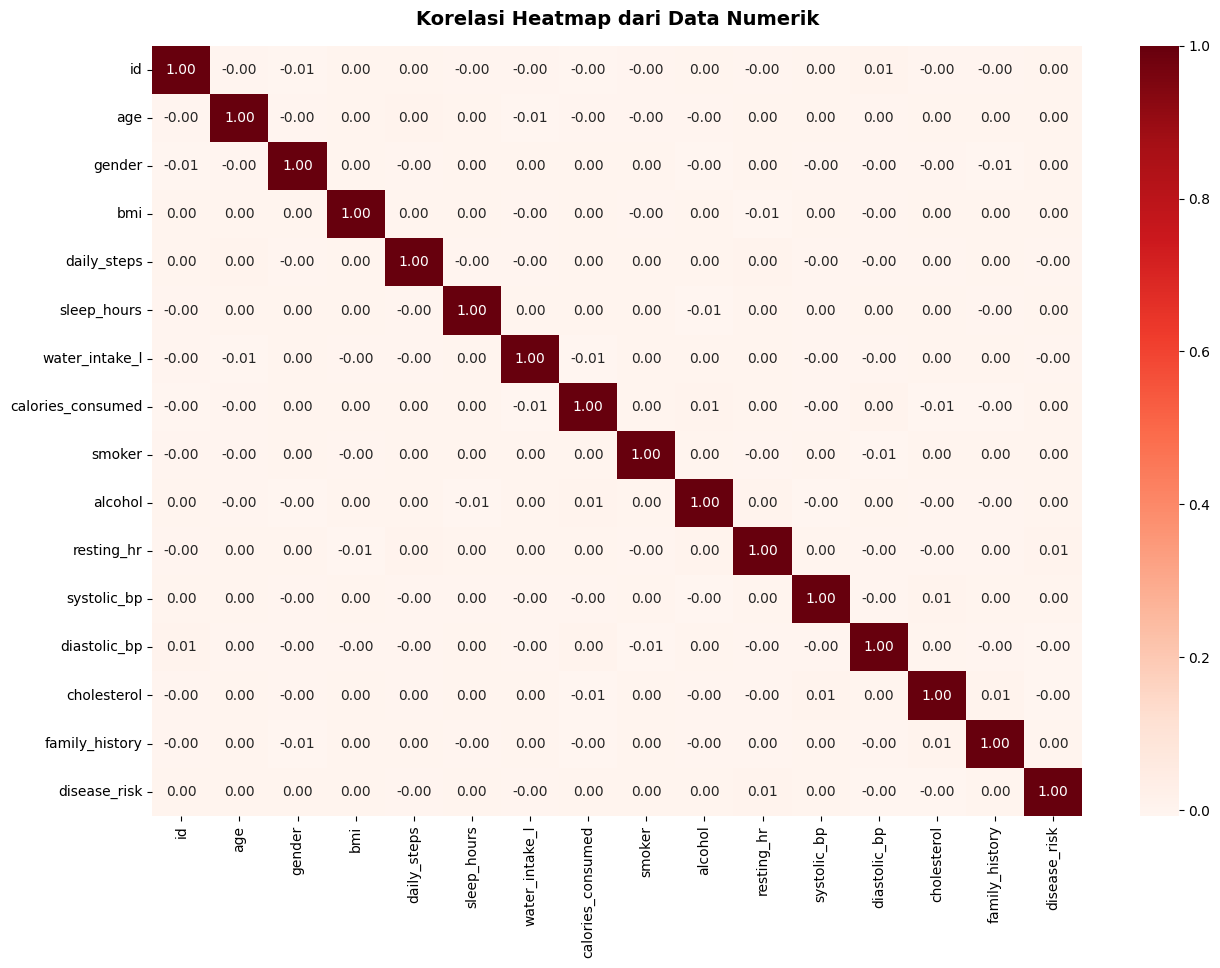

In [101]:
# membuat heatmap untuk kolom numeric
numeric_df = df_encoded.select_dtypes(include=['int64', 'float64'])

# Calculate correlation on numeric columns only
corr = numeric_df.corr()

plt.figure(figsize=(15,10))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, annot = True, cmap='Reds', fmt='.2f')
plt.title("Korelasi Heatmap dari Data Numerik", fontsize=14, pad=15, fontweight='bold')
plt.show()

Berdasarkan korelasi heatmap, tidak ditemukan nilai yang saling berkorelasi atau berhubungan antara satu sama lain variabel. Tidak terlihat ada nilai yang mendekati angka 1 (berhubungan)

In [42]:
df_baru.groupby('smoker')['cholesterol'].mean()

smoker
0    224.278928
1    224.386931
Name: cholesterol, dtype: float64

In [43]:
df_baru.groupby('alcohol')['cholesterol'].mean()

alcohol
0    224.402726
1    224.062429
Name: cholesterol, dtype: float64

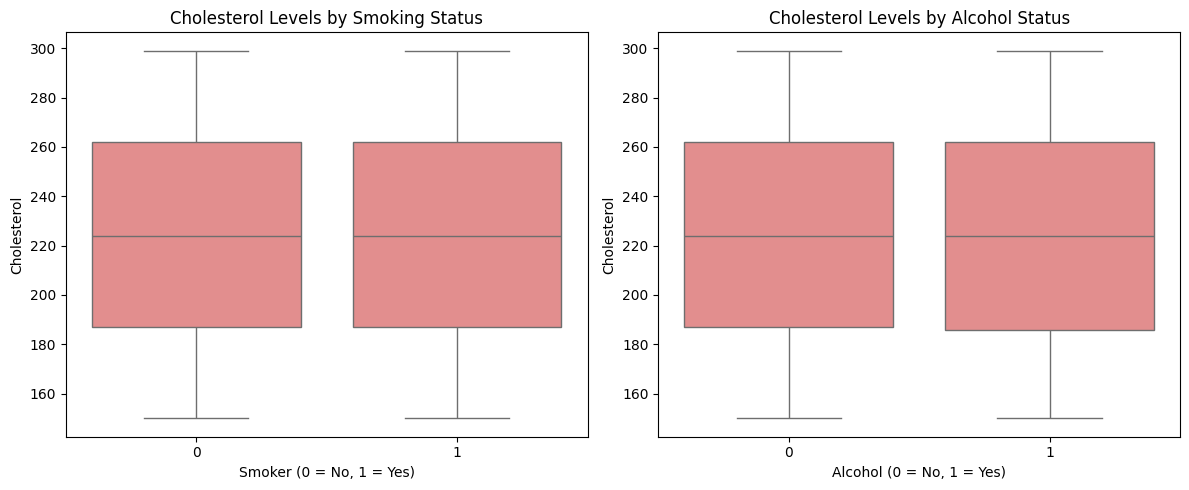

In [44]:
plt.figure(figsize=(12,5))

# Plot 1: Smoker vs Cholesterol
plt.subplot(1,2,1)
sns.boxplot(x='smoker', y='cholesterol', data=df_baru, color='lightcoral')
plt.title("Cholesterol Levels by Smoking Status")
plt.xlabel("Smoker (0 = No, 1 = Yes)")
plt.ylabel("Cholesterol")

# Plot 2: Alcohol vs Cholesterol
plt.subplot(1,2,2)
sns.boxplot(x='alcohol', y='cholesterol', data=df_baru, color='lightcoral')
plt.title("Cholesterol Levels by Alcohol Status")
plt.xlabel("Alcohol (0 = No, 1 = Yes)")
plt.ylabel("Cholesterol")

plt.tight_layout()
plt.show()

Tidak terlihat perbedaan yang signifikan pada nilai median (garis tengah di dalam kotak) tingkat kolesterol baik pada kelompok perokok maupun peminum alkohol. Median berada di kisaran angka 220-230 mg/dL.

In [45]:
df_baru.groupby('alcohol')[['systolic_bp','diastolic_bp']].mean()

,systolic_bp,diastolic_bp
alcohol,,
0,134.659090,89.469356
1,134.397573,89.600993


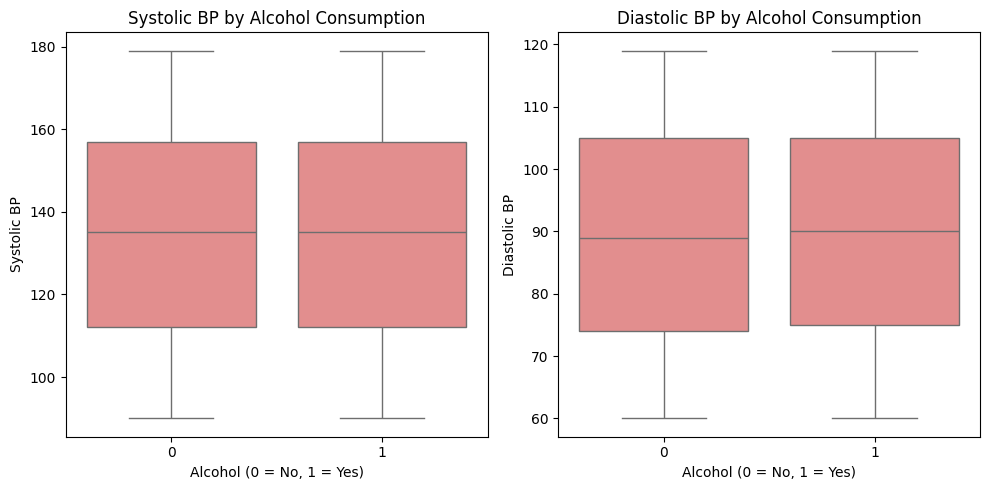

In [46]:
plt.figure(figsize=(10,5))

# Subplot 1: Systolic BP
plt.subplot(1,2,1)
sns.boxplot(x='alcohol', y='systolic_bp', data=df_baru, color='lightcoral')
plt.title("Systolic BP by Alcohol Consumption")
plt.xlabel("Alcohol (0 = No, 1 = Yes)")
plt.ylabel("Systolic BP")

# Subplot 2: Diastolic BP
plt.subplot(1,2,2)
sns.boxplot(x='alcohol', y='diastolic_bp', data=df_baru, color='lightcoral')
plt.title("Diastolic BP by Alcohol Consumption")
plt.xlabel("Alcohol (0 = No, 1 = Yes)")
plt.ylabel("Diastolic BP")

plt.tight_layout()
plt.show()

Systolic BP (Sistolik): Median tekanan darah sistolik bagi konsumen alkohol (1) dan non-konsumen (0) berada di titik yang sama, yaitu sekitar 135 mmHg. Kotak distribusi (IQR) juga menunjukkan sebaran yang serupa dari kisaran 110 hingga 160 mmHg.

Diastolic BP (Diastolik): Pola yang sama terjadi pada tekanan darah diastolik. Median berada di sekitar 90 mmHg. Meskipun ada sedikit variasi pada batas bawah kuartil bagi pengguna alkohol, secara keseluruhan perbedaannya sangat tipis.

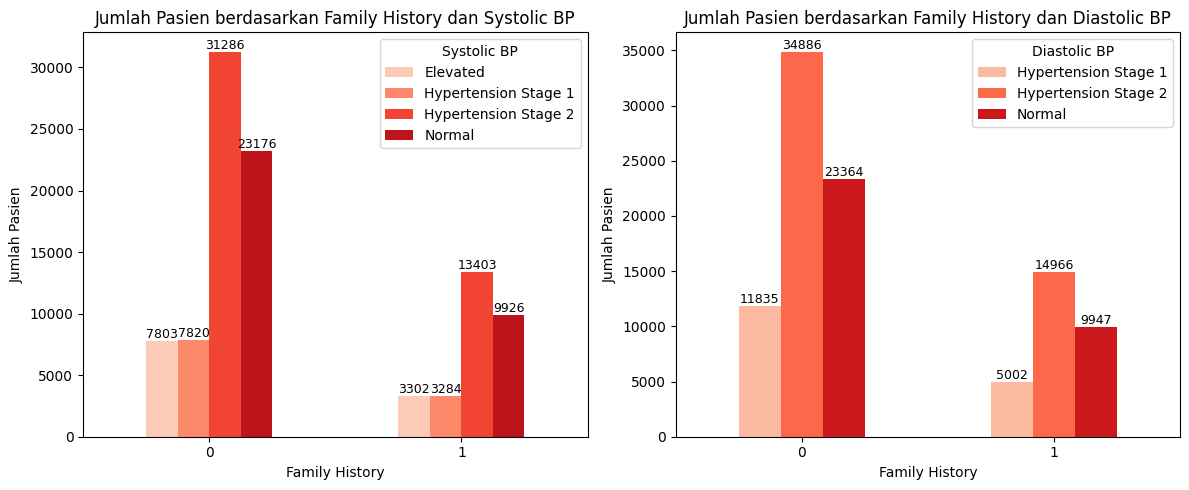

In [47]:
# groupby systolic
xy_sys = df_baru.groupby(
    ["family_history", "systolic_category"],
    observed=True
)["id"].nunique().unstack()

# groupby diastolic
xy_dia = df_baru.groupby(
    ["family_history", "diastolic_category"],
    observed=True
)["id"].nunique().unstack()


plt.figure(figsize=(12,5))

# palette merah
palette_sys = sns.color_palette("Reds", xy_sys.shape[1])
palette_dia = sns.color_palette("Reds", xy_dia.shape[1])


# Subplot 1: Systolic BP
ax1 = plt.subplot(1,2,1)
xy_sys.plot(kind="bar", ax=ax1, color=palette_sys)

ax1.set_title("Jumlah Pasien berdasarkan Family History dan Systolic BP")
ax1.set_xlabel("Family History")
ax1.set_ylabel("Jumlah Pasien")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.legend(title="Systolic BP")

# anotasi
for container in ax1.containers:
    ax1.bar_label(container, label_type="edge", fontsize=9)


# Subplot 2: Diastolic BP
ax2 = plt.subplot(1,2,2)
xy_dia.plot(kind="bar", ax=ax2, color=palette_dia)

ax2.set_title("Jumlah Pasien berdasarkan Family History dan Diastolic BP")
ax2.set_xlabel("Family History")
ax2.set_ylabel("Jumlah Pasien")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(title="Diastolic BP")

# anotasi
for container in ax2.containers:
    ax2.bar_label(container, label_type="edge", fontsize=9)


plt.tight_layout()
plt.show()

Perbandingan Volume: Jumlah pasien tanpa riwayat keluarga (0) jauh lebih besar secara keseluruhan dibandingkan pasien dengan riwayat keluarga (1) dalam dataset ini.

**Temuan Spesifik Sistolik:**

- Tanpa riwayat keluarga: 31.286 pasien berada di tahap Hypertension Stage 2.

- Dengan riwayat keluarga: 13.403 pasien berada di tahap Hypertension Stage 2.

**Temuan Spesifik Diastolik:**

- Tanpa riwayat keluarga: 34.886 pasien tercatat dalam Hypertension Stage 2.

- Dengan riwayat keluarga: 14.966 pasien tercatat dalam Hypertension Stage 2.

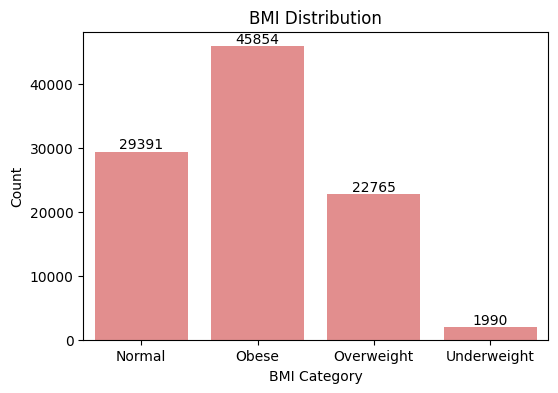

In [48]:
# proporsi BMI
plt.figure(figsize=(6,4))

ax = sns.countplot(x='bmi_category', data=df_baru, color='lightcoral')

plt.title("BMI Distribution")
plt.xlabel("BMI Category")
plt.ylabel("Count")

# Tambahkan anotasi jumlah di atas bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width()/2, height),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()

**Mayoritas Obesitas:** Kategori Obesitas memiliki jumlah pasien tertinggi, yaitu sebanyak 45.854 orang yang sering kali berkorelasi dengan risiko tekanan darah tinggi yang terlihat pada grafik.

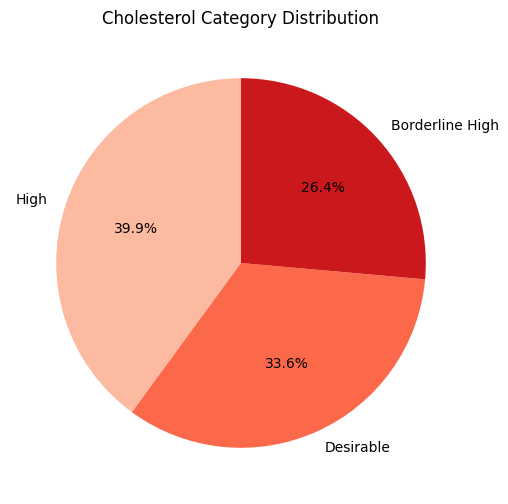

In [49]:
# Hitung jumlah tiap kategori
chol_counts = df_baru['cholesterol_category'].value_counts()

# Ambil warna dari palette Reds
colors = sns.color_palette("Reds", len(chol_counts))

plt.figure(figsize=(6,6))

plt.pie(
    chol_counts,
    labels=chol_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title("Cholesterol Category Distribution")

plt.show()

Hampir 40% (39,9%) pasien memiliki kadar kolesterol **kategori High (Tinggi).**

/var/folders/1k/sdmmxldn72x7m1dp7r9vnbg80000gn/T/ipykernel_10797/2859589909.py:8: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(


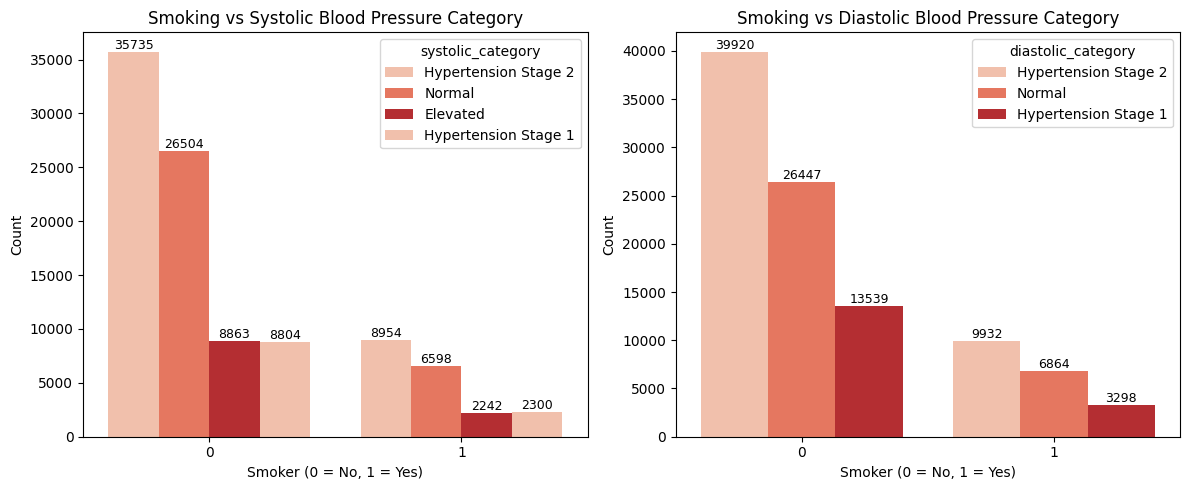

In [50]:
plt.figure(figsize=(12,5))

# palette merah
palette_red = sns.color_palette("Reds", 3)

# Plot 1: Smoker vs Systolic Category
ax1 = plt.subplot(1,2,1)
sns.countplot(
    x='smoker',
    hue='systolic_category',
    data=df_baru,
    palette=palette_red,
    ax=ax1
)

ax1.set_title("Smoking vs Systolic Blood Pressure Category")
ax1.set_xlabel("Smoker (0 = No, 1 = Yes)")
ax1.set_ylabel("Count")

# anotasi
for container in ax1.containers:
    ax1.bar_label(container, label_type="edge", fontsize=9)


# Plot 2: Smoker vs Diastolic Category
ax2 = plt.subplot(1,2,2)
sns.countplot(
    x='smoker',
    hue='diastolic_category',
    data=df_baru,
    palette=palette_red,
    ax=ax2
)

ax2.set_title("Smoking vs Diastolic Blood Pressure Category")
ax2.set_xlabel("Smoker (0 = No, 1 = Yes)")
ax2.set_ylabel("Count")

# anotasi
for container in ax2.containers:
    ax2.bar_label(container, label_type="edge", fontsize=9)


plt.tight_layout()
plt.show()

**Bukan Faktor Tunggal:** Sama seperti data riwayat keluarga, kelompok non-perokok (0) tetap memiliki angka Hypertension Stage 2 yang sangat tinggi.

**Pola Serupa:** Baik perokok maupun non-perokok menunjukkan pola yang sama, di mana hipertensi tahap 2 mendominasi dibandingkan kategori normal atau lainnya.

In [51]:
df[['cholesterol','systolic_bp','diastolic_bp']].corr()

,cholesterol,systolic_bp,diastolic_bp
cholesterol,1.000000,0.006215,0.001072
systolic_bp,0.006215,1.000000,-0.002257
diastolic_bp,0.001072,-0.002257,1.000000


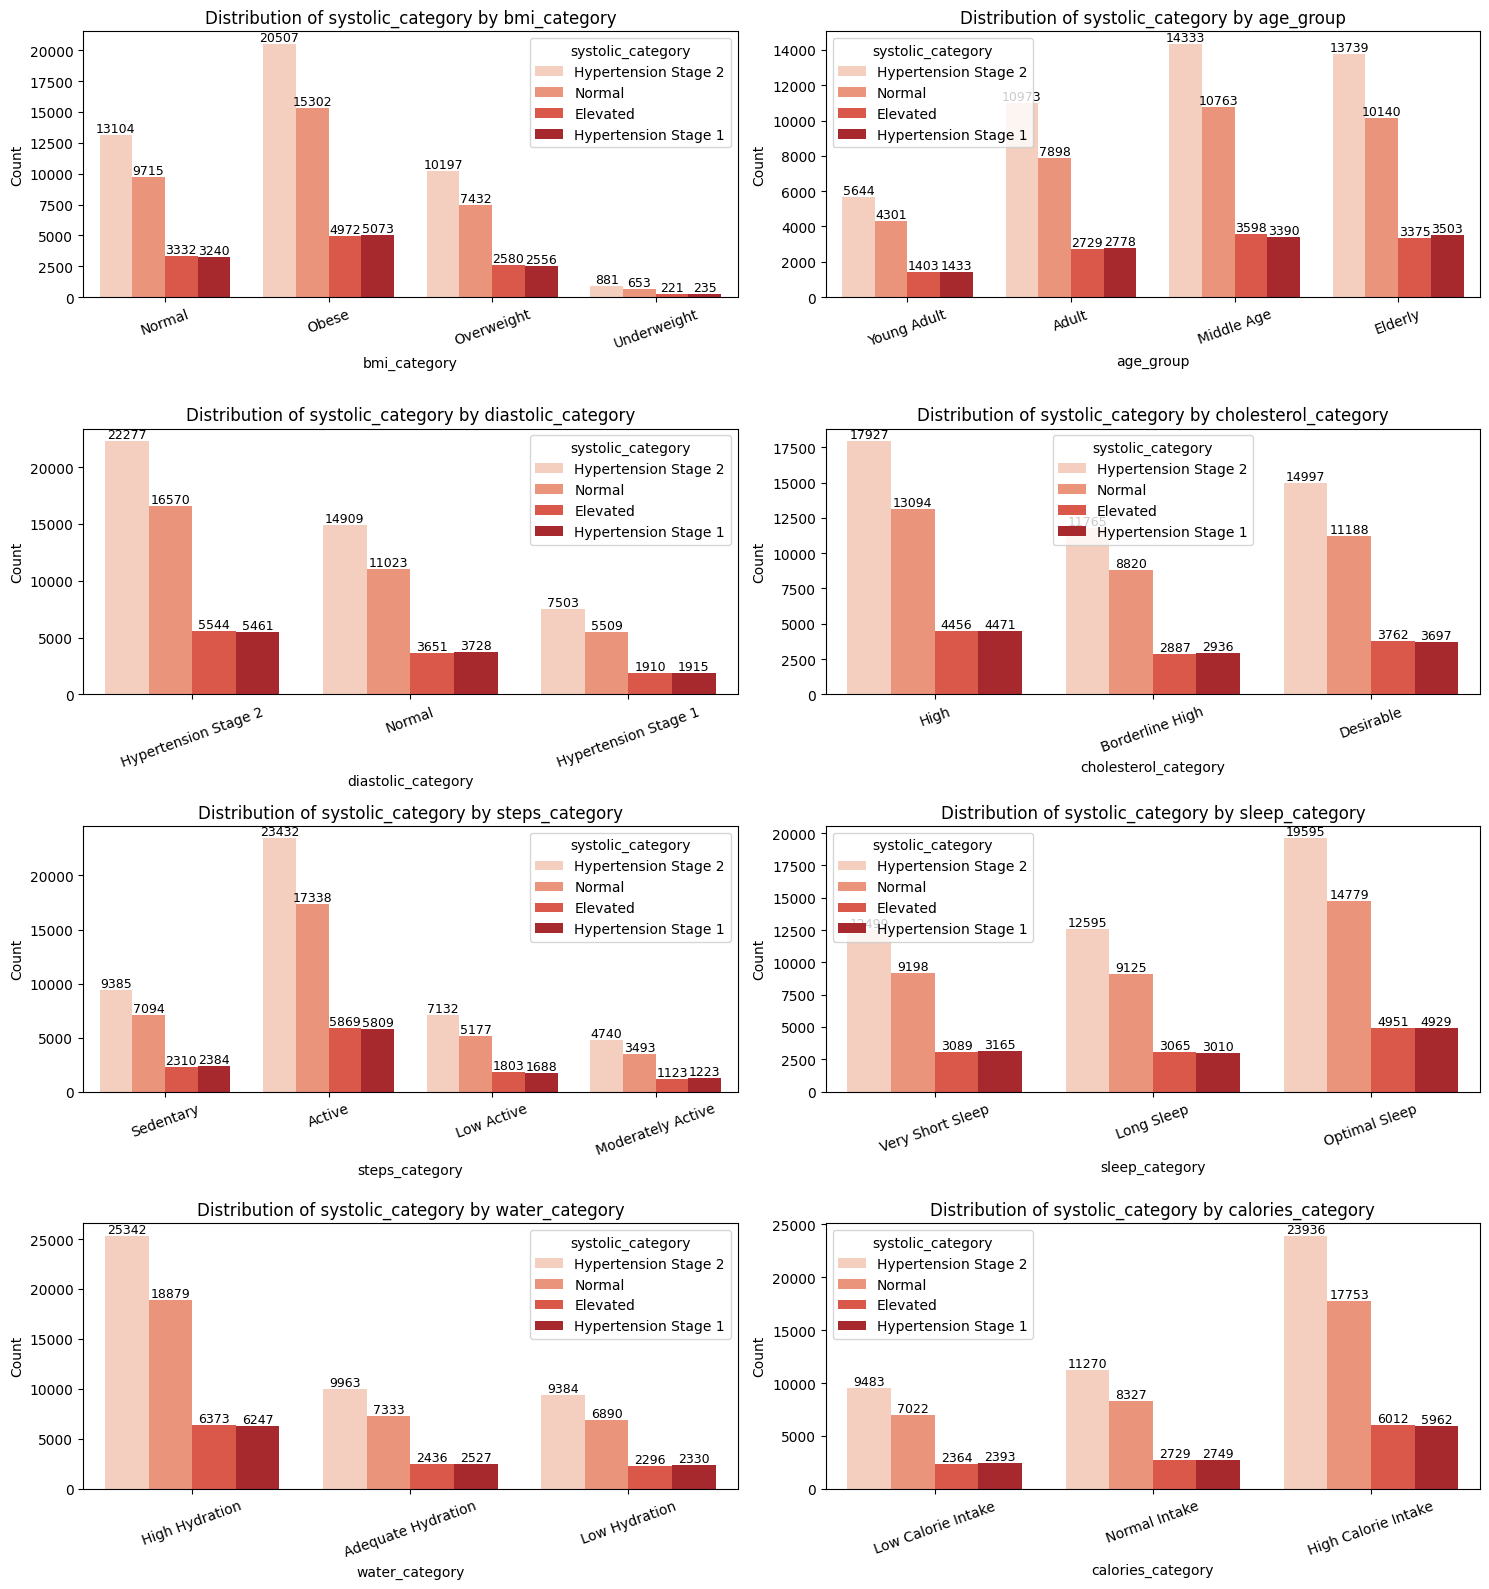

In [52]:
# Daftar variabel kategorikal yang akan dianalisis
categorical_cols = [
    'bmi_category',
    'age_group',
    'diastolic_category',
    'cholesterol_category',
    'steps_category',	
    'sleep_category',	
    'water_category',	
    'calories_category'
]

target_col = 'systolic_category'   

# Menentukan jumlah kolom subplot dalam satu baris
n_cols = 2

# Menghitung jumlah baris subplot secara otomatis
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

# Membuat figure dan kumpulan subplot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

# Pastikan axes selalu bisa di-loop (kalau cuma 1 baris, axes bukan array 2D)
axes = axes.flatten()

# Loop untuk membuat countplot pada setiap variabel kategorikal
for i, col in enumerate(categorical_cols):

    sns.countplot(
        data=df_baru,         # ganti ke df kamu (misal df_clean / df_baru)
        x=col,
        hue=target_col,
        ax=axes[i],
        palette="Reds"
    )

    # Judul & label
    axes[i].set_title(f"Distribution of {target_col} by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

    # Legend rapi
    axes[i].legend(title=target_col)

    # Rotasi label kalau kategori panjang
    axes[i].tick_params(axis='x', rotation=20)

    # Anotasi jumlah di atas bar
    for p in axes[i].patches:
        height = p.get_height()
        if height > 0:
            axes[i].annotate(
                f'{int(height)}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center',
                va='bottom',
                fontsize=9
            )

# Hapus subplot kosong jika ada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

| Visualisasi | Interpretasi |
|-------------|--------------|
| Jumlah kategori sistolik berdasarkan **BMI Category** | Pasien dalam kategori **Obese** menunjukkan jumlah kasus **Hypertension Stage 2** yang paling dominan, menandakan bahwa kelebihan berat badan merupakan faktor risiko utama terhadap tekanan darah tinggi. |
| Jumlah kategori sistolik berdasarkan **Age Group** | Risiko hipertensi meningkat secara signifikan seiring bertambahnya usia. Kelompok **Middle Age** dan **Elderly** memiliki frekuensi kasus hipertensi yang jauh lebih tinggi dibandingkan kelompok usia muda. |
| Jumlah kategori sistolik berdasarkan **Diastolic Category** | Terdapat korelasi linier yang kuat antara tekanan diastolik dan sistolik, di mana pasien dengan status diastolik **Hypertension Stage 2** cenderung memiliki status sistolik yang serupa. |
| Jumlah kategori sistolik berdasarkan **Cholesterol Category** | Pasien dengan kadar kolesterol **High** menunjukkan jumlah kasus hipertensi yang tinggi, mengindikasikan bahwa kadar kolesterol tinggi sering berkaitan dengan gangguan tekanan darah. |
| Jumlah kategori sistolik berdasarkan **Steps Category** | Meskipun kelompok **Active** memiliki populasi yang besar, distribusi kasus hipertensi masih cukup signifikan, menunjukkan bahwa aktivitas fisik saja tidak selalu menjamin tekanan darah normal tanpa dukungan gaya hidup sehat lainnya. |
| Jumlah kategori sistolik berdasarkan **Sleep Category** | Durasi **Optimal Sleep** tidak secara otomatis menurunkan jumlah kasus hipertensi pada data ini, sehingga kualitas tidur perlu dianalisis bersama faktor gaya hidup lainnya. |
| Jumlah kategori sistolik berdasarkan **Water Category** | Kelompok dengan asupan air tinggi (**High Hydration**) tercatat memiliki jumlah kasus hipertensi yang cukup besar, kemungkinan dipengaruhi oleh dominasi jumlah sampel pada kategori tersebut. |
| Jumlah kategori sistolik berdasarkan **Calories Category** | Konsumsi kalori tinggi (**High Calorie Intake**) berkontribusi besar terhadap tingginya angka **Hypertension Stage 2**, menegaskan bahwa pola makan berlebih dapat memicu tekanan darah tinggi. |

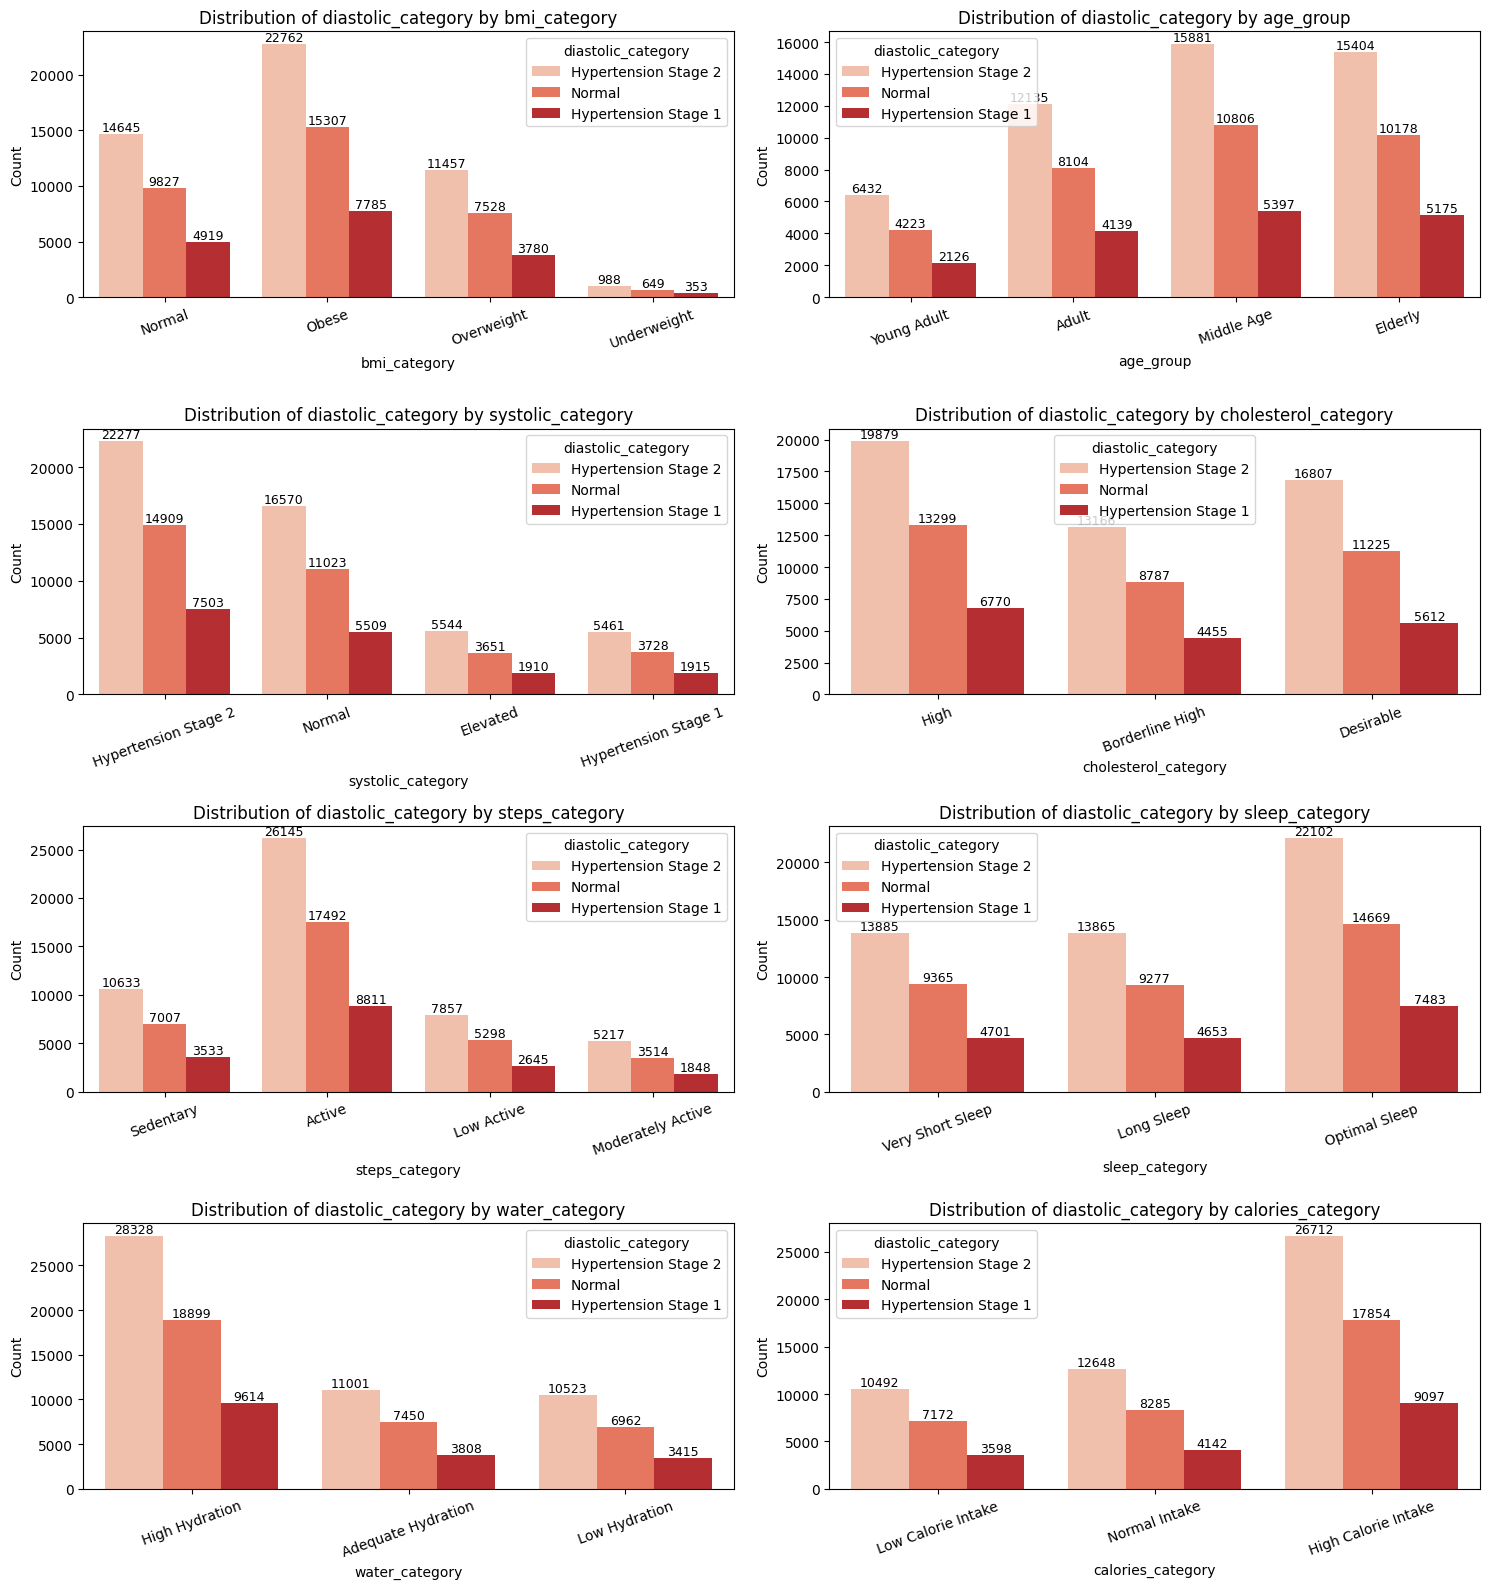

In [53]:
# Daftar variabel kategorikal yang akan dianalisis
categorical_cols = [
    'bmi_category',
    'age_group',
    'systolic_category',
    'cholesterol_category',
    'steps_category',	
    'sleep_category',	
    'water_category',	
    'calories_category'
]

target_col = 'diastolic_category'

# Menentukan jumlah kolom subplot dalam satu baris
n_cols = 2

# Menghitung jumlah baris subplot secara otomatis
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

# Membuat figure dan kumpulan subplot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

# Pastikan axes selalu bisa di-loop (kalau cuma 1 baris, axes bukan array 2D)
axes = axes.flatten()

# Loop untuk membuat countplot pada setiap variabel kategorikal
for i, col in enumerate(categorical_cols):

    sns.countplot(
        data=df_baru,         # ganti ke df kamu (misal df_clean / df_baru)
        x=col,
        hue=target_col,
        ax=axes[i],
        palette="Reds"
    )

    # Judul & label
    axes[i].set_title(f"Distribution of {target_col} by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

    # Legend rapi
    axes[i].legend(title=target_col)

    # Rotasi label kalau kategori panjang
    axes[i].tick_params(axis='x', rotation=20)

    # Anotasi jumlah di atas bar
    for p in axes[i].patches:
        height = p.get_height()
        if height > 0:
            axes[i].annotate(
                f'{int(height)}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center',
                va='bottom',
                fontsize=9
            )

# Hapus subplot kosong jika ada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Tabel Interpretasi Distribusi Kategori Tekanan Darah (Systolic & Diastolic)

| Visualisasi | Interpretasi |
| :--- | :--- |
| Distribusi kategori tekanan darah berdasarkan **bmi_category** | Pasien dalam kategori **'Obese'** menunjukkan jumlah kasus **'Hypertension Stage 2'** paling dominan (20.507 sistolik & 22.762 diastolik), menandakan berat badan berlebih sebagai faktor risiko utama tekanan darah tinggi. |
| Distribusi kategori tekanan darah berdasarkan **age_group** | Risiko hipertensi meningkat drastis seiring bertambahnya usia, di mana kelompok **'Middle Age'** dan **'Elderly'** memiliki frekuensi kasus hipertensi tahap 2 jauh lebih tinggi dibanding kelompok muda. |
| Distribusi kategori tekanan darah berdasarkan **systolic/diastolic_category** | Terdapat korelasi linier yang kuat antara tekanan darah sistolik dan diastolik; pasien dengan status **'Hypertension Stage 2'** pada satu parameter cenderung memiliki status yang serupa pada parameter lainnya. |
| Distribusi kategori tekanan darah berdasarkan **cholesterol_category** | Pasien dengan kadar kolesterol **'High'** menunjukkan angka hipertensi tahap 2 tertinggi (17.927 sistolik & 19.879 diastolik), mengindikasikan kaitan erat antara profil lipid dan kesehatan vaskular. |
| Distribusi kategori tekanan darah berdasarkan **steps_category** | Kelompok **'Active'** memiliki populasi data terbesar dengan jumlah kasus hipertensi yang tetap signifikan, menunjukkan bahwa intensitas langkah kaki saja tidak cukup tanpa kontrol faktor risiko lainnya. |
| Distribusi kategori tekanan darah berdasarkan **sleep_category** | Kategori **'Optimal Sleep'** mencatatkan jumlah kasus terbanyak dalam dataset ini, namun tetap didominasi oleh penderita hipertensi tahap 2 (19.595 sistolik & 22.102 diastolik). |
| Distribusi kategori tekanan darah berdasarkan **water_category** | Kelompok dengan asupan air tinggi (**'High Hydration'**) memiliki frekuensi kasus hipertensi tahap 2 tertinggi, yang kemungkinan besar dipengaruhi oleh dominasi jumlah sampel pada kategori tersebut. |
| Distribusi kategori tekanan darah berdasarkan **calories_category** | Konsumsi kalori tinggi (**'High Calorie Intake'**) berkontribusi besar terhadap lonjakan angka **'Hypertension Stage 2'** (23.936 sistolik & 26.712 diastolik), mempertegas dampak buruk asupan energi berlebih. |

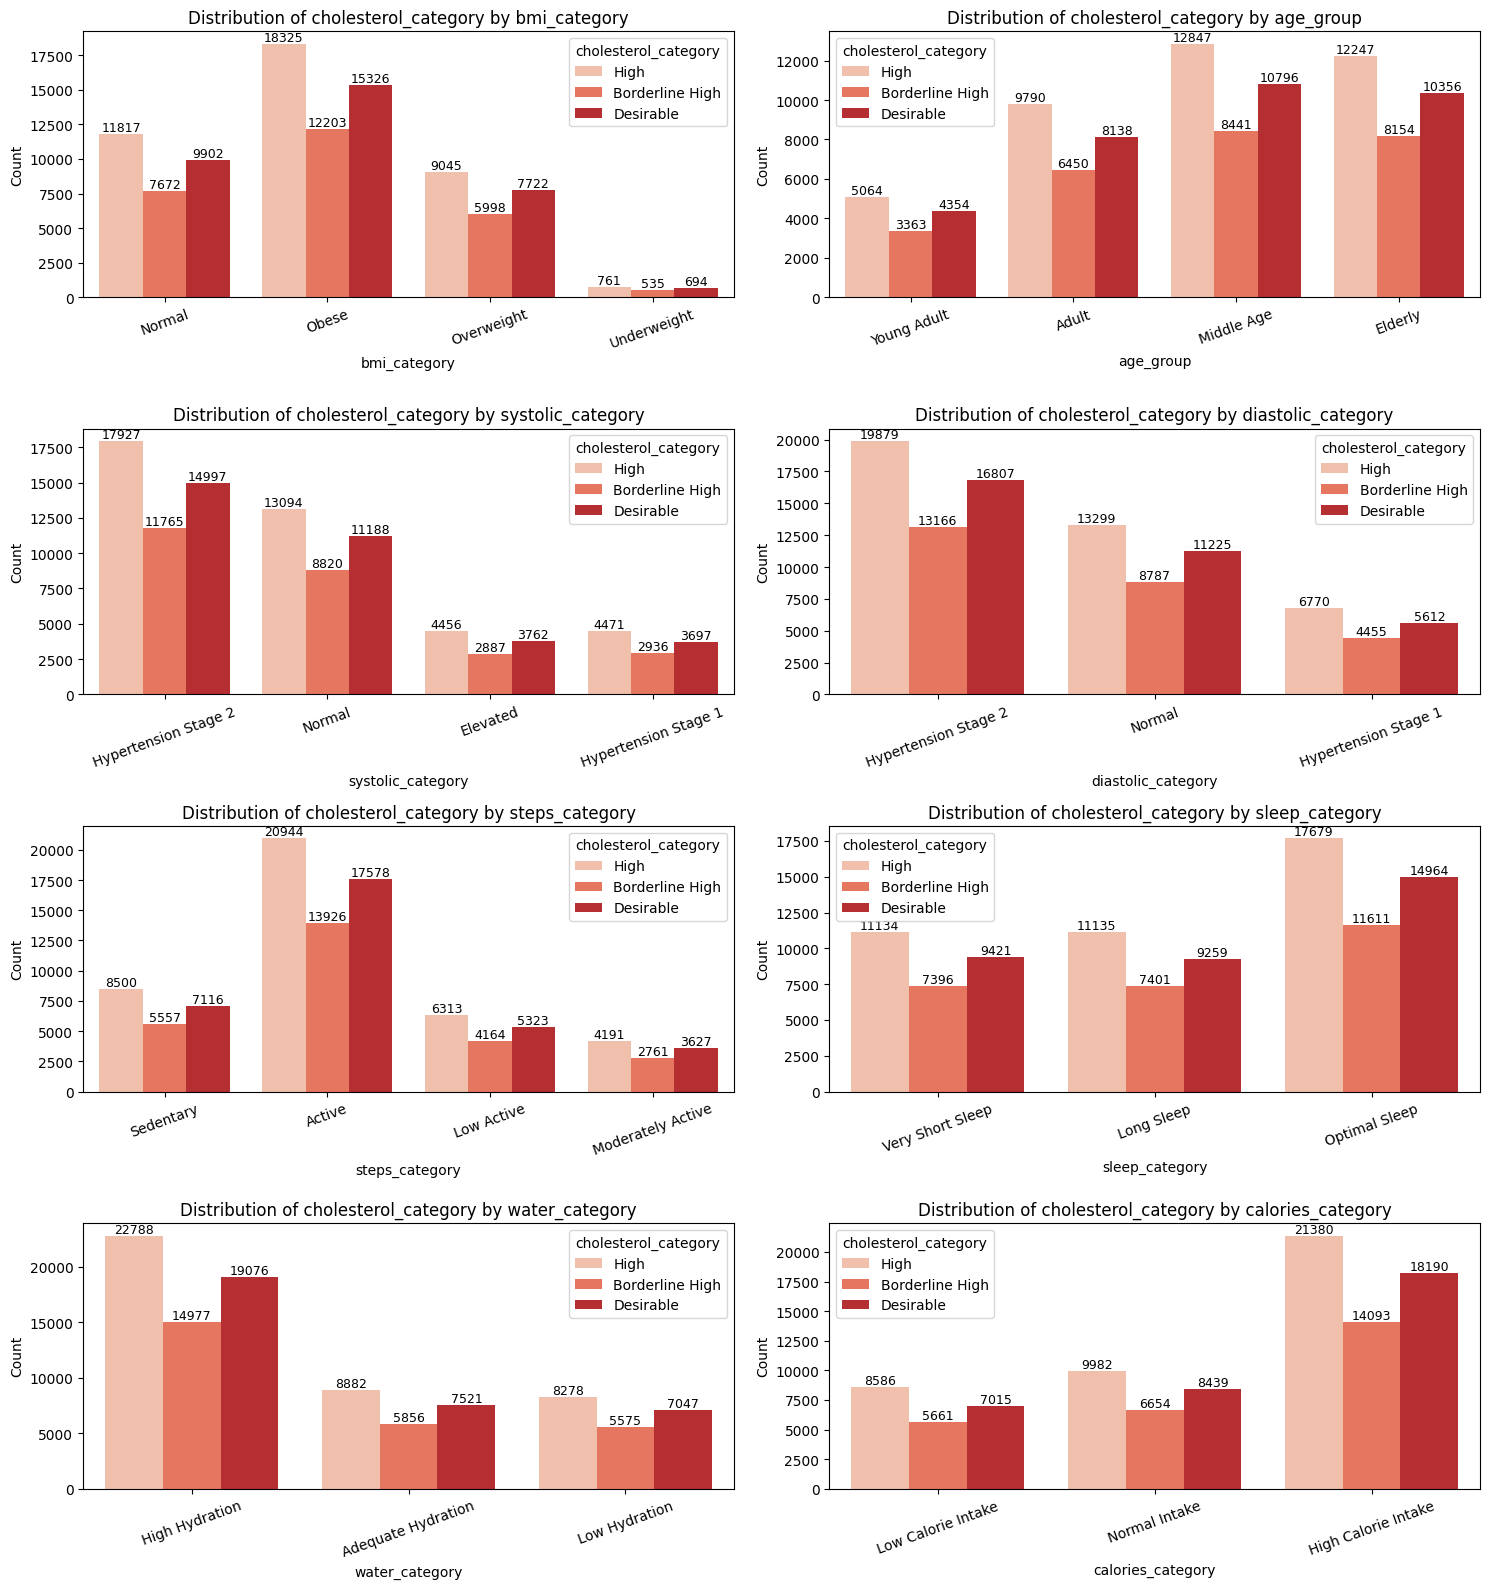

In [54]:
# Daftar variabel kategorikal yang akan dianalisis
categorical_cols = [
    'bmi_category',
    'age_group',
    'systolic_category',
    'diastolic_category',
    'steps_category',	
    'sleep_category',	
    'water_category',	
    'calories_category'
]

target_col = 'cholesterol_category'

# Menentukan jumlah kolom subplot dalam satu baris
n_cols = 2

# Menghitung jumlah baris subplot secara otomatis
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

# Membuat figure dan kumpulan subplot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

# Pastikan axes selalu bisa di-loop (kalau cuma 1 baris, axes bukan array 2D)
axes = axes.flatten()

# Loop untuk membuat countplot pada setiap variabel kategorikal
for i, col in enumerate(categorical_cols):

    sns.countplot(
        data=df_baru,         # ganti ke df kamu (misal df_clean / df_baru)
        x=col,
        hue=target_col,
        ax=axes[i],
        palette="Reds"
    )

    # Judul & label
    axes[i].set_title(f"Distribution of {target_col} by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

    # Legend rapi
    axes[i].legend(title=target_col)

    # Rotasi label kalau kategori panjang
    axes[i].tick_params(axis='x', rotation=20)

    # Anotasi jumlah di atas bar
    for p in axes[i].patches:
        height = p.get_height()
        if height > 0:
            axes[i].annotate(
                f'{int(height)}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center',
                va='bottom',
                fontsize=9
            )

# Hapus subplot kosong jika ada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Tabel Interpretasi Analisis Faktor Risiko Kesehatan

| Visualisasi | Interpretasi |
| :--- | :--- |
| Distribusi kategori kesehatan berdasarkan **bmi_category** | Kelompok **'Obese'** memiliki angka **'Hypertension Stage 2'** (20.507 sistolik) dan **'High Cholesterol'** (18.325) tertinggi, menegaskan obesitas sebagai pemicu utama komplikasi vaskular. |
| Distribusi kategori kesehatan berdasarkan **age_group** | Risiko hipertensi dan kolesterol tinggi melonjak drastis pada kelompok **'Middle Age'** dan **'Elderly'**, menunjukkan penurunan kondisi kesehatan seiring bertambahnya usia. |
| Hubungan antara **systolic** dan **diastolic_category** | Terdapat korelasi linier yang sangat kuat di mana 22.277 pasien dengan **'Hypertension Stage 2'** pada tekanan sistolik juga mengalami kondisi serupa pada tekanan diastoliknya. |
| Distribusi kategori tekanan darah berdasarkan **cholesterol_category** | Pasien dengan kolesterol **'High'** cenderung menderita hipertensi berat (17.927 sistolik), menunjukkan hubungan erat antara penumpukan lemak darah dan tekanan darah tinggi. |
| Distribusi kategori kesehatan berdasarkan **steps_category** | Meskipun kelompok **'Active'** sangat dominan secara populasi, angka hipertensi dan kolesterol tetap tinggi, menandakan olahraga saja tidak cukup tanpa kontrol pola makan. |
| Distribusi kategori kesehatan berdasarkan **sleep_category** | Responden dengan **'Optimal Sleep'** mencatatkan frekuensi kasus kesehatan buruk yang besar, mengindikasikan faktor durasi tidur tidak berdiri sendiri dalam menjaga tekanan darah. |
| Distribusi kategori kesehatan berdasarkan **water_category** | Kategori **'High Hydration'** memiliki jumlah kasus hipertensi dan kolesterol tertinggi (25.342 sistolik), yang kemungkinan besar disebabkan oleh besarnya sampel data pada kategori tersebut. |
| Distribusi kategori kesehatan berdasarkan **calories_category** | Asupan kalori berlebih (**'High Calorie Intake'**) menjadi kontributor terbesar bagi munculnya **'Hypertension Stage 2'** (23.936) dan kolesterol tinggi (21.380). |

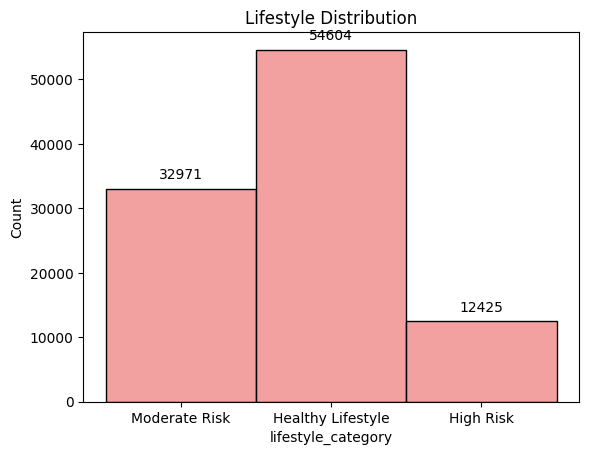

In [55]:
# Proporsi lifestyle 
sns.histplot(df_baru['lifestyle_category'], bins=20, color='lightcoral')

# Memberikan judul pada grafik
plt.title("Lifestyle Distribution")

# Opsional: Menambahkan anotasi angka di atas setiap batang (bar)
# Kode ini akan mengambil data dari objek plot dan menuliskan jumlah frekuensinya
ax = plt.gca() # Mengambil axis yang aktif saat ini
for p in ax.patches:
    if p.get_height() > 0: # Hanya memberi label jika tingginya lebih dari nol
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

Berdasarkan grafik distribusi gaya hidup:

**Healthy Lifestyle (54.604)**: Mayoritas responden berada dalam kategori gaya hidup sehat.

Moderate Risk (32.971): Sepertiga populasi memiliki risiko menengah yang memerlukan intervensi dini.

High Risk (12.425): Sebagian kecil populasi berada pada risiko tinggi yang membutuhkan penanganan medis intensif.

In [56]:
# Fixed code with proper syntax
healthy_lifestyle = df_baru[
    (df_baru['bmi_category'] == 'Normal') &
    (df_baru['daily_steps'] >= 8000) &
    (df_baru['sleep_hours'].between(7,8)) &
    (df_baru['water_intake_l'] >= 2) &
    (df_baru['smoker'] == 0) &
    (df_baru['alcohol'] == 0)
]  # Closing bracket was missing here

# Set display option outside the DataFrame filtering
pd.set_option('display.max_columns', None)

healthy_lifestyle.head(20)

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,age_group,bmi_category,systolic_category,diastolic_category,cholesterol_category,steps_category,sleep_category,water_category,calories_category,lifestyle_risk,lifestyle_category,bp_category
59,60,26,Female,24.8,16022,7.7,4.5,3494,0,0,88,111,99,177,0,1,Adult,Normal,Normal,Hypertension Stage 2,Desirable,Active,Optimal Sleep,High Hydration,High Calorie Intake,1,Healthy Lifestyle,Hypertension
117,118,35,Female,22.9,12410,7.0,2.6,1281,0,0,86,128,92,293,1,0,Adult,Normal,Elevated,Hypertension Stage 2,High,Active,Optimal Sleep,High Hydration,Low Calorie Intake,0,Healthy Lifestyle,Hypertension
124,125,77,Male,20.3,18704,7.0,4.5,2022,0,0,89,156,83,180,0,0,Elderly,Normal,Hypertension Stage 2,Hypertension Stage 1,Desirable,Active,Optimal Sleep,High Hydration,Normal Intake,0,Healthy Lifestyle,Hypertension
180,181,43,Male,23.1,17207,7.3,4.5,3943,0,0,88,168,97,214,1,0,Middle Age,Normal,Hypertension Stage 2,Hypertension Stage 2,Borderline High,Active,Optimal Sleep,High Hydration,High Calorie Intake,1,Healthy Lifestyle,Hypertension
209,210,30,Female,18.6,8722,7.2,2.3,2275,0,0,87,146,98,190,0,0,Adult,Normal,Hypertension Stage 2,Hypertension Stage 2,Desirable,Moderately Active,Optimal Sleep,Adequate Hydration,Normal Intake,0,Healthy Lifestyle,Hypertension
262,263,49,Female,19.3,14713,7.1,2.6,2086,0,0,88,103,64,191,1,0,Middle Age,Normal,Normal,Normal,Desirable,Active,Optimal Sleep,High Hydration,Normal Intake,0,Healthy Lifestyle,Normal
308,309,34,Female,19.2,17602,7.9,2.3,1474,0,0,61,133,110,191,0,1,Adult,Normal,Hypertension Stage 1,Hypertension Stage 2,Desirable,Active,Optimal Sleep,Adequate Hydration,Low Calorie Intake,0,Healthy Lifestyle,Hypertension
389,390,28,Male,20.4,19123,7.5,3.5,2547,0,0,82,130,110,247,1,0,Adult,Normal,Hypertension Stage 1,Hypertension Stage 2,High,Active,Optimal Sleep,High Hydration,High Calorie Intake,1,Healthy Lifestyle,Hypertension
485,486,50,Male,20.9,19902,7.1,2.7,1406,0,0,58,107,83,297,1,0,Middle Age,Normal,Normal,Hypertension Stage 1,High,Active,Optimal Sleep,High Hydration,Low Calorie Intake,0,Healthy Lifestyle,Normal
675,676,62,Female,22.0,13080,7.4,2.1,1919,0,0,56,158,93,247,0,0,Elderly,Normal,Hypertension Stage 2,Hypertension Stage 2,High,Active,Optimal Sleep,Adequate Hydration,Normal Intake,0,Healthy Lifestyle,Hypertension


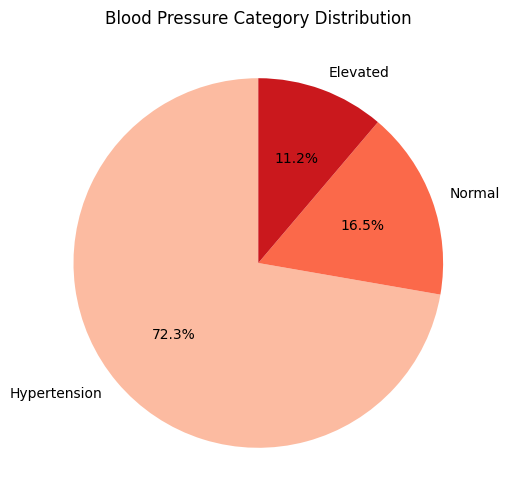

In [58]:
# Hitung jumlah tiap kategori
chol_counts = df_baru['bp_category'].value_counts()

# Ambil warna dari palette Reds
colors = sns.color_palette("Reds", len(chol_counts))

plt.figure(figsize=(6,6))

plt.pie(
    chol_counts,
    labels=chol_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title("Blood Pressure Category Distribution")

plt.show()

In [ ]:
# menyimpan kedalam excel
df_baru.to_excel("health_cleaning.xlsx", index=False)